# Project 3 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You will be allocated one of the three themes for part 2 - check announcements on canvas to see which theme is allocated to your group.

You will be working with the Cats and Dogs data set and/or the MNIST data set.

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke". 

The most structured way to do this is Nested CV. That is, an outer K-fold split into training and test and an inner CV-loop for tuning models. However, you can also use repeated random splits into training and testing instead of CV. The benefit of using CV is that the correlation between the outer splits, but a large number of random splits might be more beneficial if you want to compare many models in an outer loop. 


In [1]:
import torch 
def get_device():
    """Select device where to perform the computations."""
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Selected device: {device}")

ModuleNotFoundError: No module named 'torch'

In [39]:
# First the cats and dogs data...
import pandas as pd 

PATHIM = "C://Users//wwide//MVE441//cnd_large//images.csv"
PATHLB = "C://Users//wwide//MVE441//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

X = images
y = labels

X_images = X.reshape(-1, 64, 64)

X_cropped = X_images[:, 6:-6, 6:-6]

print("New dimensions:", X_cropped.shape[1:]) 
X_final = X_cropped.reshape(X_cropped.shape[0], -1)

print("New number of features per image:", X_final.shape[1])

Gamla mått: (64, 64)
Nya mått: (52, 52)
Nytt antal kolumner (features) per bild: 2704


In [81]:
X_cats = X_final[0:5000]
X_dogs = X_final[5000:10000]
y_cats = labels[0:5000]
y_dogs = labels[5000:10000]

print(X_cats.shape)

(5000, 2704)


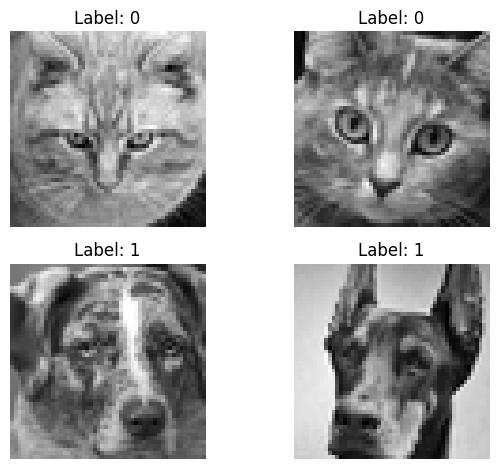

In [ ]:
# Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = X_final[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(52,52)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

# Part 1

*Everyone should do this task.*

For the first part, use the large cats and dogs dataset in order to investigate the effects of varying the sample size (n) on the method.

Use at least 4 classifiers and make sure they span a spectrum from rigid to flexible. 

Compare the Performance: Measure the performance in each method as you decrease the sample size. Also compare the performance across methods.
You should use at least 2 performance metrics, e.g. accuracy, log-loss/cross-entropy, Brier score  ($\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^K (\hat{p}_{ik}-y_{ik})^2$, where $y_{ik}=1$ when observation $i$ belongs to class k, and 0 otherwise), balanced accuracy, F1-macro, etc. The first 3 are more commonly used to compare models through repeated data splits because they mesh well with testing procedures. 

WE WILL TALK ABOUT THE FOLLOWING IN CLASS NEXT WEEK: I recommend you use rank-based tests to compare the models. That is, for each data split, obtain the ranks for all the models. Use the Friedman test to determine if there are any significant differences between model performance. If there is, perform all pairwise tests between models and adjust using the Holm procedure. Now you can either visualize these p-values in a M-by-M heat map (M models) or in a table with equivalent rank groups (e.g. Model 1, Model 3 > Model 2 > Model 4, Model 5). In Python, the \verbatim{scikit_posthocs} package has some of this implemented but you can also code from scratch. The Friedman-allpairsexact test is not available but you can use Nemenyi instead although it is more conservative.  A Bayesian variant allows for another way to create equivalent ranks through - this is implemented in a package called \verbatim{baycomp}. 

Be prepare to explain:
Which method was best and how did you evaluate this?
Did any method suprise you? 
What was your pipeline? 



In [14]:
from sklearn.model_selection import KFold, GridSearchCV, train_test_split, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score, log_loss
from sklearn.svm import SVC, LinearSVC
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from collections import Counter
import scikit_posthocs as sp
from scipy.stats import rankdata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### GridSearch functions

In [45]:
# GridSearch for CART function
def grid_search_cart(X_train, y_train, X_test, y_test):

    param_grid = {
        "criterion": ["gini", "entropy"],
        "max_features": ["sqrt", None],
        "min_samples_leaf": [1, 7, 15],
        "min_samples_split": [2, 6, 14]
        }

    CART = DecisionTreeClassifier(splitter="best")

    # Grid search
    CART_cv = GridSearchCV(
        estimator=CART,
        param_grid=param_grid,
        n_jobs=-1,
        cv=None,
    )

    CART_cv.fit(X_train, y_train)
    
    print("Best Params: {}".format(CART_cv.best_params_))

    best_params = CART_cv.best_params_
    predictions = CART_cv.predict(X_test)

        
    return {
        "accuracy": accuracy_score(y_test, predictions),
        "f1_score": f1_score(y_test, predictions),
        "brier_score": brier_score_loss(y_test, predictions),
        "log_loss": log_loss(y_test, predictions),
        **best_params
        }

In [46]:
# GridSearch for Random Forest

def grid_search_rf(X_train, y_train, X_test, y_test):
    param_grid = {
        "n_estimators": [100, 200],              # 300 träd tar lång tid i onödan under grid search
        "criterion": ["gini", "entropy"],
        "max_features": ["sqrt", "log2"],         # Bort med 1500 och None om du vill ha fart
        "min_samples_leaf": [1, 10],
        "min_samples_split": [2, 10]              # Starta på 2!
    }

    # TA BORT n_jobs=-1 härifrån!
    RF = RandomForestClassifier() 

    # Grid search
    RF_cv = GridSearchCV(
        estimator=RF,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,)                         

    RF_cv.fit(X_train, y_train)
    
    print("Best Params: {}".format(RF_cv.best_params_))
    
    best_params = RF_cv.best_params_
    predictions = RF_cv.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, predictions),
        "f1_score": f1_score(y_test, predictions),
        "brier_score": brier_score_loss(y_test, predictions),
        "log_loss": log_loss(y_test, predictions),
        **best_params
        }

In [47]:
# GridSearch for Linear SVM

from sklearn.svm import LinearSVC

def grid_search_svm(X_train, y_train, X_test, y_test):
    
    param_grid = {
        "C": [0.1, 1, 10],
        }

    SVM = LinearSVC()

    SVM_cv = GridSearchCV(
        estimator=SVM,
        param_grid=param_grid,
        cv=5,
        n_jobs=-1,
    )

    SVM_cv.fit(X_train, y_train)
    best_params = SVM_cv.best_params_
    predictions = SVM_cv.predict(X_test)
    
    print("Best Params: {}".format(SVM_cv.best_params_))
    return {"accuracy": accuracy_score(y_test, predictions),
            "f1_score": f1_score(y_test, predictions),
            "brier_score": brier_score_loss(y_test, predictions),
            "log_loss": log_loss(y_test, predictions),
            **best_params}

In [48]:
# GridSearch for Logistic Regression
def grid_search_logreg(X_train, y_train, X_test, y_test):

    param_grid = {
        "C": [0.001, 0.01, 0.1, 10], #np.logspace(-3, 1, 30),
        }

    LOGREG = LogisticRegression(solver = "lbfgs", penalty="l2", max_iter = 10000) # ridge

    # Grid search
    LOGREG_cv = GridSearchCV(
        estimator=LOGREG,
        param_grid=param_grid,
        cv=None
    )

    LOGREG_cv.fit(X_train, y_train)
    
    print("Best Params: {}".format(LOGREG_cv.best_params_))

    best_params = LOGREG_cv.best_params_
    predictions = LOGREG_cv.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, predictions),
        "f1_score": f1_score(y_test, predictions),
        "brier_score": brier_score_loss(y_test, predictions),
        "log_loss": log_loss(y_test, predictions),
        **best_params
        }

### 10 Repeated 10-fold CV

In [88]:
R = 10
K = 10
size = 2500

results_cart_list = []
results_rf_list = []
results_SVM_list = []
results_logreg_list = []

for r in range(R):
    X_dogs_sample = X_dogs[np.random.choice(X_dogs.shape[0], size = size, replace = False)]
    X_cats_sample = X_cats[np.random.choice(X_cats.shape[0], size = size, replace = False)]
    X = np.concatenate([X_cats_sample, X_dogs_sample])
    y = np.concatenate([np.zeros(size), np.ones(size)])
    kf = KFold(n_splits=K, shuffle=True, random_state=42)
     
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        pca = PCA(n_components=40, svd_solver= 'full')
        pca_train = pca.fit_transform(X_train)
        pca_val = pca.transform(X_test)

        results_cart = grid_search_cart(pca_train, y_train, pca_val, y_test)
        results_cart["repeat"] = r
        results_cart["fold"] = len(results_cart_list) % K
        results_cart_list.append(results_cart)

        results_rf = grid_search_rf(pca_train, y_train, pca_val, y_test)
        results_rf["repeat"] = r
        results_rf["fold"] = len(results_rf_list) % K
        results_rf_list.append(results_rf)

        results_SVM = grid_search_svm(pca_train, y_train, pca_val, y_test)
        results_SVM["repeat"] = r
        results_SVM["fold"] = len(results_SVM_list) % K
        results_SVM_list.append(results_SVM)

        results_logreg = grid_search_logreg(pca_train, y_train, pca_val, y_test)
        results_logreg["repeat"] = r
        results_logreg["fold"] = len(results_logreg_list) % K
        results_logreg_list.append(results_logreg)

    df_cart = pd.DataFrame(results_cart_list)
    df_cart.to_csv("results_cart.csv", index=False)

    df_rf = pd.DataFrame(results_rf_list)
    df_rf.to_csv("results_rf.csv", index=False)

    df_SVM = pd.DataFrame(results_SVM_list)
    df_SVM.to_csv("results_SVM.csv", index=False)

    df_logreg = pd.DataFrame(results_logreg_list)
    df_logreg.to_csv("results_logreg.csv", index=False)

Best Params: {'criterion': 'gini', 'max_features': None, 'min_samples_leaf': 15, 'min_samples_split': 14}
Best Params: {'criterion': 'gini', 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Params: {'C': 10}
Best Params: {'C': 0.001}
Best Params: {'criterion': 'gini', 'max_features': None, 'min_samples_leaf': 15, 'min_samples_split': 2}
Best Params: {'criterion': 'entropy', 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best Params: {'C': 1}
Best Params: {'C': 0.001}
Best Params: {'criterion': 'gini', 'max_features': None, 'min_samples_leaf': 15, 'min_samples_split': 2}
Best Params: {'criterion': 'gini', 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Params: {'C': 0.1}
Best Params: {'C': 0.001}
Best Params: {'criterion': 'gini', 'max_features': None, 'min_samples_leaf': 15, 'min_samples_split': 14}
Best Params: {'criterion': 'entropy', 'max_fea

## Model comparisson

In [9]:
# Load results from CSV files, change the paths if needed

results_cart = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_cart_1000.csv") 
results_rf = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_rf_1000.csv")
results_SVM = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_SVM_1000.csv")
results_logreg = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_logreg_1000.csv")


In [10]:
# Count frequency of best hyperparameters for each model

frequency_cart = Counter(zip(results_cart["criterion"], results_cart["min_samples_leaf"], results_cart["min_samples_split"])).most_common(5)
frequency_rf = Counter(zip(results_rf["n_estimators"], results_rf["criterion"], results_rf["max_features"], results_rf["min_samples_leaf"], results_rf["min_samples_split"])).most_common(5)
frequency_logreg = Counter(results_logreg["C"]).most_common(5)
frequency_SVM = Counter(results_SVM["C"]).most_common(5)

print("Result CART:",dict(frequency_cart))
print("Result RF:",dict(frequency_rf))
print("Result LOGREG:",dict(frequency_logreg))
print("Result SVM:",dict(frequency_SVM))

Result CART: {('entropy', 15, 6): 14, ('gini', 15, 2): 13, ('entropy', 15, 2): 10, ('gini', 15, 14): 9, ('entropy', 7, 2): 8}
Result RF: {(200, 'gini', 'sqrt', 1, 2): 21, (200, 'entropy', 'log2', 1, 2): 16, (200, 'entropy', 'sqrt', 1, 2): 15, (200, 'gini', 'log2', 1, 2): 13, (200, 'gini', 'log2', 1, 10): 9}
Result LOGREG: {0.001: 100}
Result SVM: {0.1: 65, 1.0: 23, 10.0: 12}


### Results

In [33]:
PATHIM = "C://Users//wwide//MVE441//cnd_large//images.csv"
PATHLB = "C://Users//wwide//MVE441//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)
labels = labels.rename(columns={"0":"label"})
images = np.array(images)
labels = np.array(labels).ravel()

X = images
y = labels

X_images = X.reshape(-1, 64, 64)
X_cropped = X_images[:, 6:-6, 6:-6]
X_final = X_cropped.reshape(X_cropped.shape[0], -1)

X_cats = X_final[0:5000]
X_dogs = X_final[5000:10000]
y_cats = labels[0:5000]
y_dogs = labels[5000:10000]

In [34]:
plot_acc_cart, plot_acc_rf, plot_acc_SVM, plot_acc_logreg = [], [], [], []
plot_f1_cart, plot_f1_rf, plot_f1_SVM, plot_f1_logreg = [], [], [], []
plot_brier_cart, plot_brier_rf, plot_brier_SVM, plot_brier_logreg = [], [], [], []
plot_logloss_cart, plot_logloss_rf, plot_logloss_SVM, plot_logloss_logreg = [], [], [], []

#### 5000 balanced
Result CART: {('gini', 15, 6): 27, ('gini', 15, 14): 23, ('gini', 15, 2): 18, ('entropy', 15, 2): 15, ('entropy', 15, 14): 7} 

Result RF: {(200, 'gini', 'log2', 1, 2): 36, (200, 'entropy', 'log2', 1, 2): 29, (200, 'gini', 'sqrt', 1, 2): 16, (200, 'gini', 'log2', 1, 10): 9, (200, 'entropy', 'sqrt', 1, 2): 4}

Result LOGREG: {0.001: 97, 0.01: 3}

Result SVM: {0.1: 45, 1.0: 35, 10.0: 20}


In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
size = 5000
X_dogs_sample = X_dogs[np.random.choice(X_dogs.shape[0], size = size, replace = False)]
X_cats_sample = X_cats[np.random.choice(X_cats.shape[0], size = size, replace = False)]
X = np.concatenate([X_cats_sample, X_dogs_sample])
y = np.concatenate([np.zeros(size), np.ones(size)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

CART_5000 = DecisionTreeClassifier(splitter="best", criterion="gini", max_features=None, min_samples_leaf=15, min_samples_split=6)
RF_5000 = RandomForestClassifier(n_estimators=200, criterion="gini", max_features="log2", min_samples_leaf=1, min_samples_split=2)
LOGREG_5000 = LogisticRegression(solver = "lbfgs", penalty="l2", max_iter = 100000, C=0.001)
SVM_5000 = LinearSVC(C=0.1)

pca_5000 = PCA(n_components=40, svd_solver='full')
pca_train_5000 = pca_5000.fit_transform(X_train)
pca_test_5000 = pca_5000.transform(X_test)

CART_5000.fit(pca_train_5000, y_train)
RF_5000.fit(pca_train_5000, y_train)
LOGREG_5000.fit(pca_train_5000, y_train)
SVM_5000.fit(pca_train_5000, y_train)

pred_cart_5000 = CART_5000.predict(pca_test_5000)
pred_rf_5000 = RF_5000.predict(pca_test_5000)
pred_logreg_5000 = LOGREG_5000.predict(pca_test_5000)
pred_SVM_5000 = SVM_5000.predict(pca_test_5000)


plot_acc_cart.append(accuracy_score(y_test, pred_cart_5000))
plot_acc_rf.append(accuracy_score(y_test, pred_rf_5000))
plot_acc_SVM.append(accuracy_score(y_test, pred_SVM_5000))
plot_acc_logreg.append(accuracy_score(y_test, pred_logreg_5000))

plot_f1_cart.append(f1_score(y_test, pred_cart_5000))
plot_f1_rf.append(f1_score(y_test, pred_rf_5000))
plot_f1_SVM.append(f1_score(y_test, pred_SVM_5000))
plot_f1_logreg.append(f1_score(y_test, pred_logreg_5000))

plot_brier_cart.append(brier_score_loss(y_test, pred_cart_5000))
plot_brier_rf.append(brier_score_loss(y_test, pred_rf_5000))
plot_brier_SVM.append(brier_score_loss(y_test, pred_SVM_5000))
plot_brier_logreg.append(brier_score_loss(y_test, pred_logreg_5000))

plot_logloss_cart.append(log_loss(y_test, pred_cart_5000))
plot_logloss_rf.append(log_loss(y_test, pred_rf_5000))
plot_logloss_SVM.append(log_loss(y_test, pred_SVM_5000))
plot_logloss_logreg.append(log_loss(y_test, pred_logreg_5000))

#### 2500 balanced

Result CART: {('gini', 15, 14): 19, ('gini', 15, 2): 17, ('gini', 15, 6): 16, ('entropy', 15, 14): 10, ('entropy', 15, 2): 9}

Result RF: {(200, 'gini', 'log2', 1, 2): 31, (200, 'entropy', 'log2', 1, 2): 21, (200, 'gini', 'sqrt', 1, 2): 18, (200, 'entropy', 'sqrt', 1, 2): 9, (200, 'gini', 'sqrt', 1, 10): 5}

Result LOGREG: {0.001: 97, 0.01: 3}

Result SVM: {0.1: 44, 1.0: 35, 10.0: 21}

In [36]:
size = 2500
X_dogs_sample = X_dogs[np.random.choice(X_dogs.shape[0], size = size, replace = False)]
X_cats_sample = X_cats[np.random.choice(X_cats.shape[0], size = size, replace = False)]
X = np.concatenate([X_cats_sample, X_dogs_sample])
y = np.concatenate([np.zeros(size), np.ones(size)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

CART_2500 = DecisionTreeClassifier(splitter="best", criterion="gini", max_features=None, min_samples_leaf=15, min_samples_split=14)
RF_2500 = RandomForestClassifier(n_estimators=200, criterion="gini", max_features="log2", min_samples_leaf=1, min_samples_split=2)
LOGREG_2500 = LogisticRegression(solver = "lbfgs", penalty="l2", max_iter = 10000, C=0.001)
SVM_2500 = LinearSVC(C=0.1)

pca_2500 = PCA(n_components=40, svd_solver='full')
pca_train_2500 = pca_2500.fit_transform(X_train)
pca_test_2500 = pca_2500.transform(X_test)

CART_2500.fit(pca_train_2500, y_train)
RF_2500.fit(pca_train_2500, y_train)
LOGREG_2500.fit(pca_train_2500, y_train)
SVM_2500.fit(pca_train_2500, y_train)

pred_cart_2500 = CART_2500.predict(pca_test_2500)
pred_rf_2500 = RF_2500.predict(pca_test_2500)
pred_logreg_2500 = LOGREG_2500.predict(pca_test_2500)
pred_SVM_2500 = SVM_2500.predict(pca_test_2500)


plot_acc_cart.append(accuracy_score(y_test, pred_cart_2500))
plot_acc_rf.append(accuracy_score(y_test, pred_rf_2500))
plot_acc_SVM.append(accuracy_score(y_test, pred_SVM_2500))
plot_acc_logreg.append(accuracy_score(y_test, pred_logreg_2500))

plot_f1_cart.append(f1_score(y_test, pred_cart_2500))
plot_f1_rf.append(f1_score(y_test, pred_rf_2500))
plot_f1_SVM.append(f1_score(y_test, pred_SVM_2500))
plot_f1_logreg.append(f1_score(y_test, pred_logreg_2500))

plot_brier_cart.append(brier_score_loss(y_test, pred_cart_2500))
plot_brier_rf.append(brier_score_loss(y_test, pred_rf_2500))
plot_brier_SVM.append(brier_score_loss(y_test, pred_SVM_2500))
plot_brier_logreg.append(brier_score_loss(y_test, pred_logreg_2500))

plot_logloss_cart.append(log_loss(y_test, pred_cart_2500))
plot_logloss_rf.append(log_loss(y_test, pred_rf_2500))
plot_logloss_SVM.append(log_loss(y_test, pred_SVM_2500))
plot_logloss_logreg.append(log_loss(y_test, pred_logreg_2500))

#### 1000 balanced

Result CART: {('entropy', 15, 6): 14, ('gini', 15, 2): 13, ('entropy', 15, 2): 10, ('gini', 15, 14): 9, ('entropy', 7, 2): 8}

Result RF: {(200, 'gini', 'sqrt', 1, 2): 21, (200, 'entropy', 'log2', 1, 2): 16, (200, 'entropy', 'sqrt', 1, 2): 15, (200, 'gini', 'log2', 1, 2): 13, (200, 'gini', 'log2', 1, 10): 9}

Result LOGREG: {0.001: 100}

Result SVM: {0.1: 65, 1.0: 23, 10.0: 12}

In [37]:
size = 1000
X_dogs_sample = X_dogs[np.random.choice(X_dogs.shape[0], size = size, replace = False)]
X_cats_sample = X_cats[np.random.choice(X_cats.shape[0], size = size, replace = False)]
X = np.concatenate([X_cats_sample, X_dogs_sample])
y = np.concatenate([np.zeros(size), np.ones(size)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

CART_1000 = DecisionTreeClassifier(splitter="best", criterion="entropy", max_features=None, min_samples_leaf=15, min_samples_split=6)
RF_1000 = RandomForestClassifier(n_estimators=200, criterion="gini", max_features="sqrt", min_samples_leaf=1, min_samples_split=2)
LOGREG_1000 = LogisticRegression(solver = "lbfgs", penalty="l2", max_iter = 10000, C=0.001)
SVM_1000 = LinearSVC(C=0.1)

pca_1000 = PCA(n_components=40, svd_solver='full')
pca_train_1000 = pca_1000.fit_transform(X_train)
pca_test_1000 = pca_1000.transform(X_test)

CART_1000.fit(pca_train_1000, y_train)
RF_1000.fit(pca_train_1000, y_train)
LOGREG_1000.fit(pca_train_1000, y_train)
SVM_1000.fit(pca_train_1000, y_train)

pred_cart_1000 = CART_1000.predict(pca_test_1000)
pred_rf_1000 = RF_1000.predict(pca_test_1000)
pred_logreg_1000 = LOGREG_1000.predict(pca_test_1000)
pred_SVM_1000 = SVM_1000.predict(pca_test_1000)


plot_acc_cart.append(accuracy_score(y_test, pred_cart_1000))
plot_acc_rf.append(accuracy_score(y_test, pred_rf_1000))
plot_acc_SVM.append(accuracy_score(y_test, pred_SVM_1000))
plot_acc_logreg.append(accuracy_score(y_test, pred_logreg_1000))

plot_f1_cart.append(f1_score(y_test, pred_cart_1000))
plot_f1_rf.append(f1_score(y_test, pred_rf_1000))
plot_f1_SVM.append(f1_score(y_test, pred_SVM_1000))
plot_f1_logreg.append(f1_score(y_test, pred_logreg_1000))

plot_brier_cart.append(brier_score_loss(y_test, pred_cart_1000))
plot_brier_rf.append(brier_score_loss(y_test, pred_rf_1000))
plot_brier_SVM.append(brier_score_loss(y_test, pred_SVM_1000))
plot_brier_logreg.append(brier_score_loss(y_test, pred_logreg_1000))

plot_logloss_cart.append(log_loss(y_test, pred_cart_1000))
plot_logloss_rf.append(log_loss(y_test, pred_rf_1000))
plot_logloss_SVM.append(log_loss(y_test, pred_SVM_1000))
plot_logloss_logreg.append(log_loss(y_test, pred_logreg_1000))

#### 500 balanced

Result CART: {('entropy', 15, 2): 14, ('gini', 15, 6): 13, ('gini', 15, 2): 10, ('entropy', 1, 2): 8, ('gini', 7, 2): 7}

Result RF: {(200, 'gini', 'sqrt', 1, 2): 23, (200, 'entropy', 'sqrt', 1, 2): 18, (200, 'gini', 'log2', 1, 2): 11, (200, 'entropy', 'log2', 1, 2): 8, (200, 'entropy', 'sqrt', 1, 10): 6}

Result LOGREG: {0.001: 99, 0.01: 1}

Result SVM: {0.1: 70, 1.0: 19, 10.0: 11}

In [38]:
size = 500
X_dogs_sample = X_dogs[np.random.choice(X_dogs.shape[0], size = size, replace = False)]
X_cats_sample = X_cats[np.random.choice(X_cats.shape[0], size = size, replace = False)]
X = np.concatenate([X_cats_sample, X_dogs_sample])
y = np.concatenate([np.zeros(size), np.ones(size)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

CART_500 = DecisionTreeClassifier(splitter="best", criterion="entropy", max_features=None, min_samples_leaf=15, min_samples_split=2)
RF_500 = RandomForestClassifier(n_estimators=200, criterion="gini", max_features="sqrt", min_samples_leaf=1, min_samples_split=2)
LOGREG_500 = LogisticRegression(solver = "lbfgs", penalty="l2", max_iter = 10000, C=0.001)
SVM_500 = LinearSVC(C=0.1)

pca_500 = PCA(n_components=40, svd_solver='full')
pca_train_500 = pca_500.fit_transform(X_train)
pca_test_500 = pca_500.transform(X_test)

CART_500.fit(pca_train_500, y_train)
RF_500.fit(pca_train_500, y_train)
LOGREG_500.fit(pca_train_500, y_train)
SVM_500.fit(pca_train_500, y_train)

pred_cart_500 = CART_500.predict(pca_test_500)
pred_rf_500 = RF_500.predict(pca_test_500)
pred_logreg_500 = LOGREG_500.predict(pca_test_500)
pred_SVM_500 = SVM_500.predict(pca_test_500)


plot_acc_cart.append(accuracy_score(y_test, pred_cart_500))
plot_acc_rf.append(accuracy_score(y_test, pred_rf_500))
plot_acc_SVM.append(accuracy_score(y_test, pred_SVM_500))
plot_acc_logreg.append(accuracy_score(y_test, pred_logreg_500))

plot_f1_cart.append(f1_score(y_test, pred_cart_500))
plot_f1_rf.append(f1_score(y_test, pred_rf_500))
plot_f1_SVM.append(f1_score(y_test, pred_SVM_500))
plot_f1_logreg.append(f1_score(y_test, pred_logreg_500))

plot_brier_cart.append(brier_score_loss(y_test, pred_cart_500))
plot_brier_rf.append(brier_score_loss(y_test, pred_rf_500))
plot_brier_SVM.append(brier_score_loss(y_test, pred_SVM_500))
plot_brier_logreg.append(brier_score_loss(y_test, pred_logreg_500))

plot_logloss_cart.append(log_loss(y_test, pred_cart_500))
plot_logloss_rf.append(log_loss(y_test, pred_rf_500))
plot_logloss_SVM.append(log_loss(y_test, pred_SVM_500))
plot_logloss_logreg.append(log_loss(y_test, pred_logreg_500))

#### 100 balanced

Result CART: {('entropy', 1, 6): 12, ('gini', 1, 14): 10, ('gini', 7, 2): 9, ('entropy', 1, 14): 9, ('entropy', 1, 2): 9}

Result RF: {(200, 'gini', 'sqrt', 1, 2): 14, (200, 'gini', 'log2', 1, 2): 11, (100, 'entropy', 'log2', 1, 2): 7, (200, 'entropy', 'sqrt', 1, 2): 7, (200, 'entropy', 'log2', 1, 2): 6}

Result LOGREG: {0.001: 72, 10.0: 11, 0.01: 9, 0.1: 8}

Result SVM: {0.1: 79, 1.0: 15, 10.0: 6}

In [39]:
size = 100
X_dogs_sample = X_dogs[np.random.choice(X_dogs.shape[0], size = size, replace = False)]
X_cats_sample = X_cats[np.random.choice(X_cats.shape[0], size = size, replace = False)]
X = np.concatenate([X_cats_sample, X_dogs_sample])
y = np.concatenate([np.zeros(size), np.ones(size)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

CART_100 = DecisionTreeClassifier(splitter="best", criterion="entropy", max_features=None, min_samples_leaf=1, min_samples_split=6)
RF_100 = RandomForestClassifier(n_estimators=200, criterion="gini", max_features="sqrt", min_samples_leaf=1, min_samples_split=2)
LOGREG_100 = LogisticRegression(solver = "lbfgs", penalty="l2", max_iter = 10000, C=0.001)
SVM_100 = LinearSVC(C=0.1)

pca_100 = PCA(n_components=40, svd_solver='full')
pca_train_100 = pca_100.fit_transform(X_train)
pca_test_100 = pca_100.transform(X_test)

CART_100.fit(pca_train_100, y_train)
RF_100.fit(pca_train_100, y_train)
LOGREG_100.fit(pca_train_100, y_train)
SVM_100.fit(pca_train_100, y_train)

pred_cart_100 = CART_100.predict(pca_test_100)
pred_rf_100 = RF_100.predict(pca_test_100)
pred_logreg_100 = LOGREG_100.predict(pca_test_100)
pred_SVM_100 = SVM_100.predict(pca_test_100)


plot_acc_cart.append(accuracy_score(y_test, pred_cart_100))
plot_acc_rf.append(accuracy_score(y_test, pred_rf_100))
plot_acc_SVM.append(accuracy_score(y_test, pred_SVM_100))
plot_acc_logreg.append(accuracy_score(y_test, pred_logreg_100))

plot_f1_cart.append(f1_score(y_test, pred_cart_100))
plot_f1_rf.append(f1_score(y_test, pred_rf_100))
plot_f1_SVM.append(f1_score(y_test, pred_SVM_100))
plot_f1_logreg.append(f1_score(y_test, pred_logreg_100))

plot_brier_cart.append(brier_score_loss(y_test, pred_cart_100))
plot_brier_rf.append(brier_score_loss(y_test, pred_rf_100))
plot_brier_SVM.append(brier_score_loss(y_test, pred_SVM_100))
plot_brier_logreg.append(brier_score_loss(y_test, pred_logreg_100))

plot_logloss_cart.append(log_loss(y_test, pred_cart_100))
plot_logloss_rf.append(log_loss(y_test, pred_rf_100))
plot_logloss_SVM.append(log_loss(y_test, pred_SVM_100))
plot_logloss_logreg.append(log_loss(y_test, pred_logreg_100))

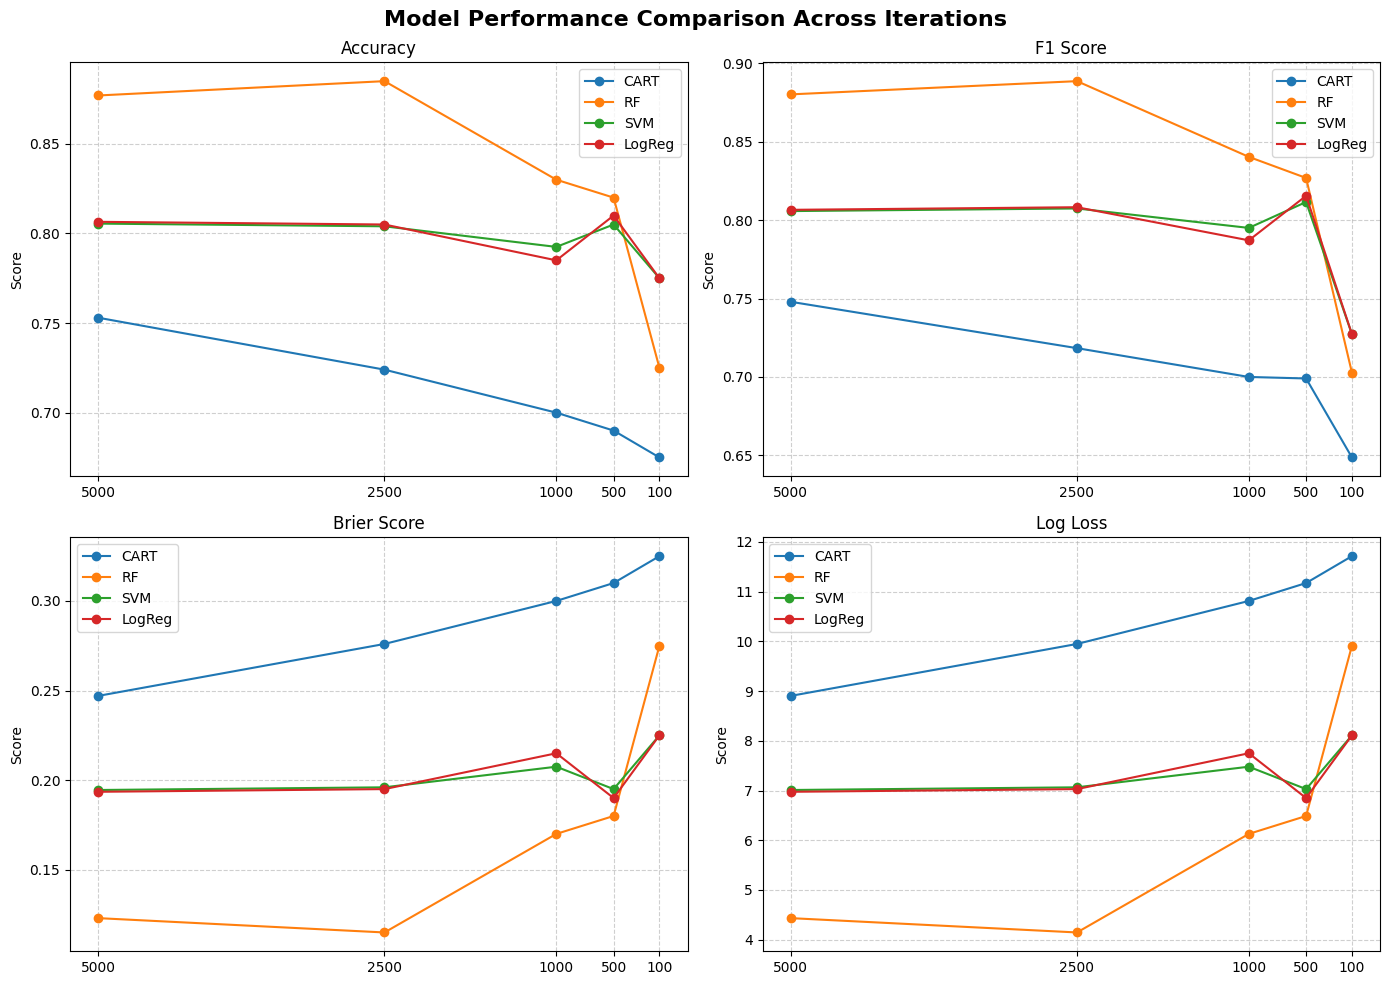

In [41]:
import matplotlib.pyplot as plt

# (Dina listor förutsätts vara laddade och fyllda här)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
sample = [5000, 2500, 1000, 500, 100]
# --- Subplot 1: Accuracy (Uppe till vänster) ---
axs[0, 0].plot(sample, plot_acc_cart, label='CART', marker='o')
axs[0, 0].plot(sample, plot_acc_rf, label='RF', marker='o')
axs[0, 0].plot(sample, plot_acc_SVM, label='SVM', marker='o')
axs[0, 0].plot(sample, plot_acc_logreg, label='LogReg', marker='o')
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Score')
axs[0, 0].set_xticks(sample)  
axs[0, 0].invert_xaxis()
axs[0, 0].legend() # Visar vilken linje som tillhör vilken modell
axs[0, 0].grid(True, linestyle='--', alpha=0.6) # Valfritt: Lägger till ett snyggt rutnät

# --- Subplot 2: F1 Score (Uppe till höger) ---
axs[0, 1].plot(sample, plot_f1_cart, label='CART', marker='o')
axs[0, 1].plot(sample, plot_f1_rf, label='RF', marker='o')
axs[0, 1].plot(sample, plot_f1_SVM, label='SVM', marker='o')
axs[0, 1].plot(sample, plot_f1_logreg, label='LogReg', marker='o')
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_ylabel('Score')
axs[0, 1].set_xticks(sample)  
axs[0, 1].invert_xaxis()
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle='--', alpha=0.6)

# --- Subplot 3: Brier Score (Nere till vänster) ---
axs[1, 0].plot(sample, plot_brier_cart, label='CART', marker='o')
axs[1, 0].plot(sample, plot_brier_rf, label='RF', marker='o')
axs[1, 0].plot(sample, plot_brier_SVM, label='SVM', marker='o')
axs[1, 0].plot(sample, plot_brier_logreg, label='LogReg', marker='o')
axs[1, 0].set_title('Brier Score')
axs[1, 0].set_ylabel('Score')
axs[1, 0].set_xticks(sample)  
axs[1, 0].invert_xaxis()
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle='--', alpha=0.6)

# --- Subplot 4: Log Loss (Nere till höger) ---
axs[1, 1].plot(sample, plot_logloss_cart, label='CART', marker='o')
axs[1, 1].plot(sample, plot_logloss_rf, label='RF', marker='o')
axs[1, 1].plot(sample, plot_logloss_SVM, label='SVM', marker='o')
axs[1, 1].plot(sample, plot_logloss_logreg, label='LogReg', marker='o')
axs[1, 1].set_title('Log Loss')
axs[1, 1].set_ylabel('Score')
axs[1, 1].set_xticks(sample)  
axs[1, 1].invert_xaxis()
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle='--', alpha=0.6)

# Överrubrik för hela figuren
plt.suptitle('Model Performance Comparison Across Iterations', fontsize=16, fontweight='bold')
plt.tight_layout()  
plt.show()

## Boxplots and critical difference diagram (Nemenyi Test)

#### 5000

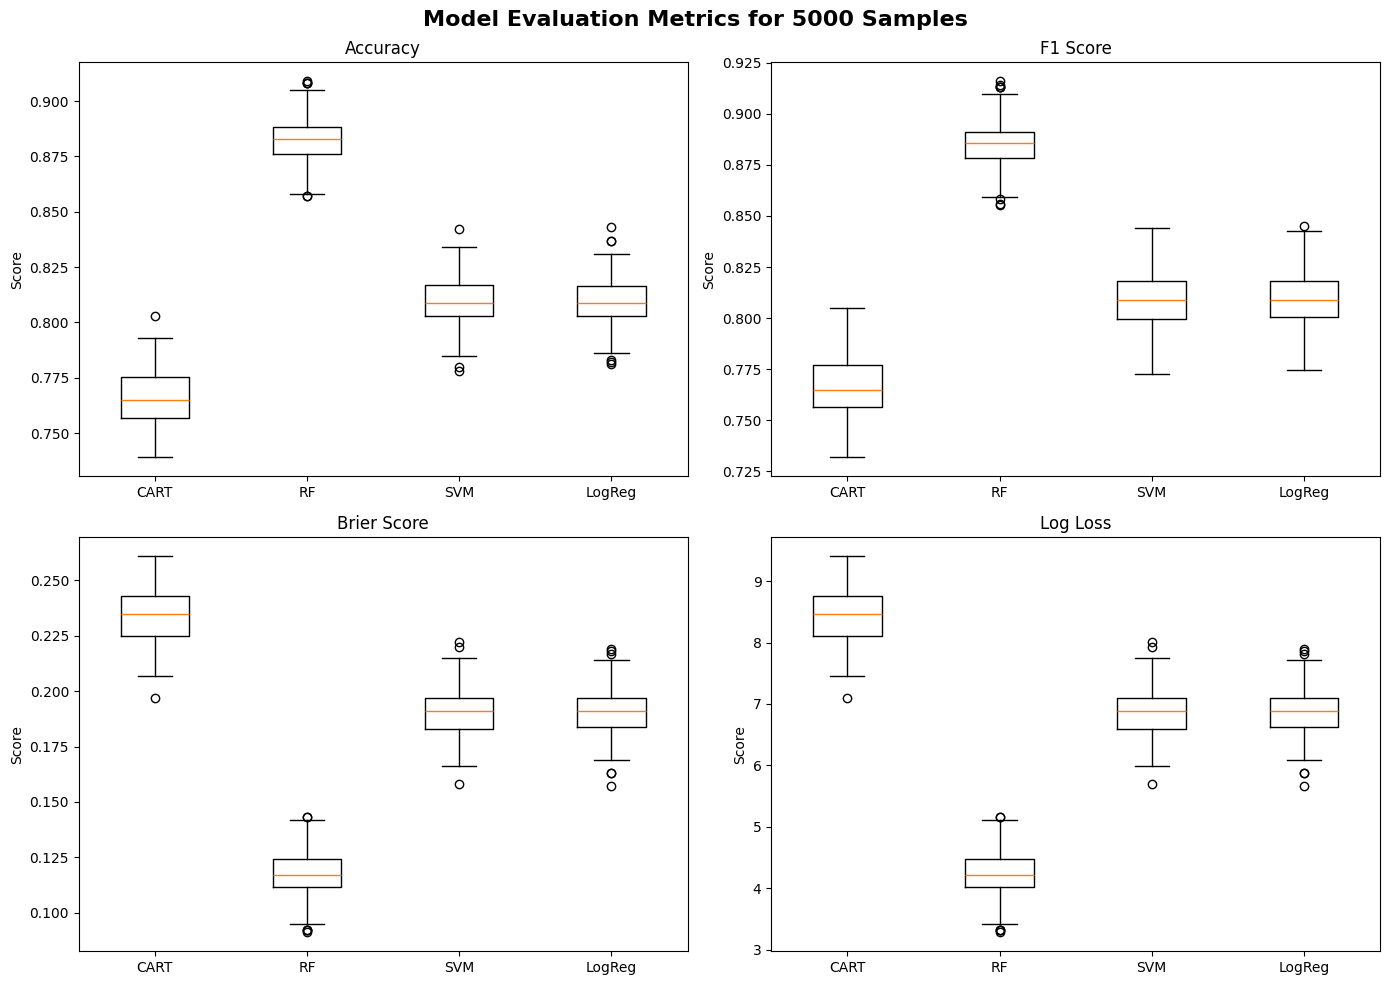

NEMENYI POST-HOC TEST (Accuracy)

P-values (Lower Triangular):
        CART   RF       SVM    LogReg
CART     1.0  0.0  0.000000  0.000000
RF       0.0  1.0  0.000000  0.000000
SVM      0.0  0.0  1.000000  0.999941
LogReg   0.0  0.0  0.999941  1.000000

Symmetric P-value Matrix:
        CART   RF       SVM    LogReg
CART     1.0  0.0  0.000000  0.000000
RF       0.0  1.0  0.000000  0.000000
SVM      0.0  0.0  1.000000  0.999941
LogReg   0.0  0.0  0.999941  1.000000
CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)


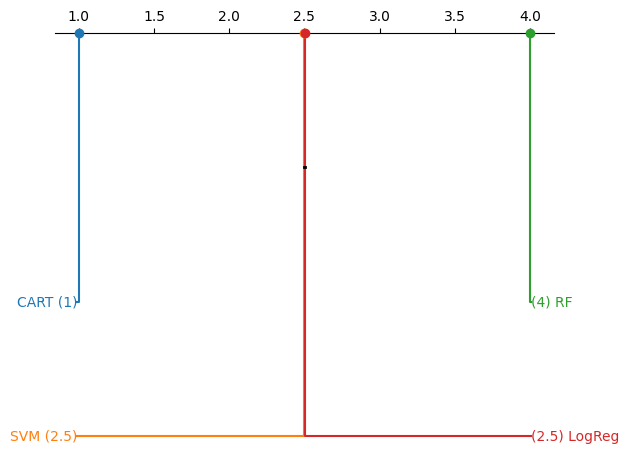

In [42]:
_5000_results_cart = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_cart_5000_5000.csv") 
_5000_results_rf = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_rf_5000_5000.csv")
_5000_results_SVM = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_SVM_5000_5000.csv")
_5000_results_logreg = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_logreg_5000_5000.csv")


labels = ['CART', 'RF', 'SVM', 'LogReg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))


_5000_acc_cart = _5000_results_cart['accuracy'].to_numpy()
_5000_acc_rf = _5000_results_rf['accuracy'].to_numpy()
_5000_acc_SVM = _5000_results_SVM['accuracy'].to_numpy()
_5000_acc_logreg = _5000_results_logreg['accuracy'].to_numpy()


axs[0, 0].boxplot([_5000_acc_cart, _5000_acc_rf, _5000_acc_SVM, _5000_acc_logreg], tick_labels=labels)
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Score')


_5000_f1_cart = _5000_results_cart['f1_score'].to_numpy()
_5000_f1_rf = _5000_results_rf['f1_score'].to_numpy()
_5000_f1_SVM = _5000_results_SVM['f1_score'].to_numpy()
_5000_f1_logreg = _5000_results_logreg['f1_score'].to_numpy()

axs[0, 1].boxplot([_5000_f1_cart, _5000_f1_rf, _5000_f1_SVM, _5000_f1_logreg], tick_labels=labels)
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_ylabel('Score')


_5000_brier_cart = _5000_results_cart['brier_score'].to_numpy()
_5000_brier_rf = _5000_results_rf['brier_score'].to_numpy()
_5000_brier_SVM = _5000_results_SVM['brier_score'].to_numpy()
_5000_brier_logreg = _5000_results_logreg['brier_score'].to_numpy()

axs[1, 0].boxplot([_5000_brier_cart, _5000_brier_rf, _5000_brier_SVM, _5000_brier_logreg], tick_labels=labels)
axs[1, 0].set_title('Brier Score')
axs[1, 0].set_ylabel('Score')


_5000_log_loss_cart = _5000_results_cart['log_loss'].to_numpy()
_5000_log_loss_rf = _5000_results_rf['log_loss'].to_numpy()
_5000_log_loss_SVM = _5000_results_SVM['log_loss'].to_numpy()
_5000_log_loss_logreg = _5000_results_logreg['log_loss'].to_numpy()

axs[1, 1].boxplot([_5000_log_loss_cart, _5000_log_loss_rf, _5000_log_loss_SVM, _5000_log_loss_logreg], tick_labels=labels)
axs[1, 1].set_title('Log Loss')
axs[1, 1].set_ylabel('Score')


plt.suptitle('Model Evaluation Metrics for 5000 Samples', fontsize=16, fontweight='bold')
plt.tight_layout()  
plt.show()

accuracy = pd.DataFrame({'CART': _5000_acc_cart, 'RF': _5000_acc_rf, 'SVM': _5000_acc_SVM, 'LogReg':_5000_acc_logreg})
print("=" * 70)
print("NEMENYI POST-HOC TEST (Accuracy)")
print("=" * 70)

# Use built-in Nemenyi test from scikit_posthocs
p_nemenyi = sp.posthoc_nemenyi_friedman(accuracy)

print("\nP-values (Lower Triangular):")
print(p_nemenyi.round(6))

# Create symmetric version for downstream analysis
p_nemenyi_sym = np.array(p_nemenyi, copy=True, dtype=float)
i_lower = np.tril_indices(p_nemenyi_sym.shape[0], -1)
p_nemenyi_sym[i_lower[1], i_lower[0]] = p_nemenyi_sym[i_lower]
np.fill_diagonal(p_nemenyi_sym, 1)

print("\nSymmetric P-value Matrix:")
print(pd.DataFrame(np.round(p_nemenyi_sym, 6), 
                   index=accuracy.columns, 
                   columns=accuracy.columns))


# Compute average ranks for CD diagram
ranks = np.array([rankdata(row) for row in accuracy.values])
mean_ranks = ranks.mean(axis=0)

# Convert mean_ranks to Series with proper index to match p-value matrix
mean_ranks_series = pd.Series(mean_ranks, index=accuracy.columns)

# Create CD diagram
print("=" * 70)
print("CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)")
print("=" * 70)

# Create symmetric p-value DataFrame for CD diagram
p_nemenyi_for_cd = pd.DataFrame(p_nemenyi_sym, 
                                 index=accuracy.columns, 
                                 columns=accuracy.columns)

# Use scikit_posthocs critical_difference_diagram with p-value matrix
sp.critical_difference_diagram(mean_ranks_series, p_nemenyi_for_cd, alpha=0.05)
plt.tight_layout()
plt.show()

        CART   RF    SVM  LogReg
CART     0.5  0.0  0.000   0.000
RF       1.0  0.5  1.000   1.000
SVM      1.0  0.0  0.500   0.002
LogReg   1.0  0.0  0.003   0.500
        CART   RF    SVM  LogReg
CART     1.0  0.0  0.000   0.000
RF       0.0  1.0  0.000   0.000
SVM      0.0  0.0  1.000   0.995
LogReg   0.0  0.0  0.995   1.000


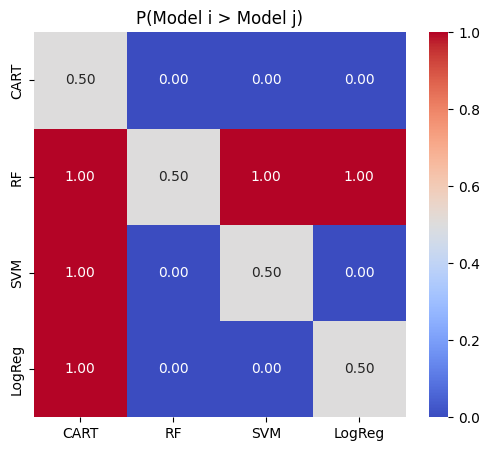

In [43]:
from itertools import combinations

def estimate_global_sigma(data):
    """
    Estimate a global standard deviation from pairwise differences.

    Parameters
    ----------
    data : array-like, shape (B, M)
        Rows = runs, columns = models

    Returns
    -------
    sigma : float
        Global standard deviation estimate
    """

    data = np.asarray(data)
    M = data.shape[1]

    sigmas = []

    for i, j in combinations(range(M), 2):
        diff = data[:, i] - data[:, j]
        sigmas.append(np.std(diff, ddof=1))

    return np.mean(sigmas)

def compute_rope(data, d_threshold=0.1):
    """
    Compute a global ROPE based on Cohen's d threshold.

    Parameters
    ----------
    data : array (B, M)
    d_threshold : float
        e.g. 0.1 (very small), 0.2 (small)

    Returns
    -------
    rope : float
    """

    sigma = estimate_global_sigma(data)

    rope = d_threshold * sigma

    return rope


from baycomp import two_on_single # pip install baycomp
 
scores = accuracy.to_dict(orient='list')  # Convert DataFrame to dict of lists

rope_val = compute_rope(accuracy.values, d_threshold=0.2)


models = list(scores.keys())
M = len(models)

# Initialize result matrix -----------------------------------------------
Pmat = np.full((M, M), np.nan)
np.fill_diagonal(Pmat, 0.5)

Pties = np.full((M, M), np.nan)
np.fill_diagonal(Pties, 1)

# Pairwise baycomp --------------------------------------------------------
for i in range(M - 1):
    for j in range(i + 1, M):

        bc = two_on_single(
            np.array(scores[models[i]]),
            np.array(scores[models[j]]),
            rope=rope_val,
            runs=10
        )
        probs = bc
        # bc returns (p_left, p_rope, p_right) = (P(i>j), P(equivalent), P(j>i))

        Pmat[i, j] = probs[0]  # P(i > j)
        Pmat[j, i] = probs[2]  # P(j > i)
        Pties[i, j] = probs[1]  # P(i = j)
        Pties[j, i] = probs[1]  # P(j = i)

# Convert to DataFrame for nice matrix display
Pmat_df = pd.DataFrame(Pmat, index=models, columns=models)
print(Pmat_df.round(3))

Pties_df = pd.DataFrame(Pties, index=models, columns=models)
print(Pties_df.round(3))

import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    Pmat,  #t(Pmat) if lower is better
    xticklabels=models,
    yticklabels=models,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0.5
)
plt.title("P(Model i > Model j)")
plt.show()

#### 2500

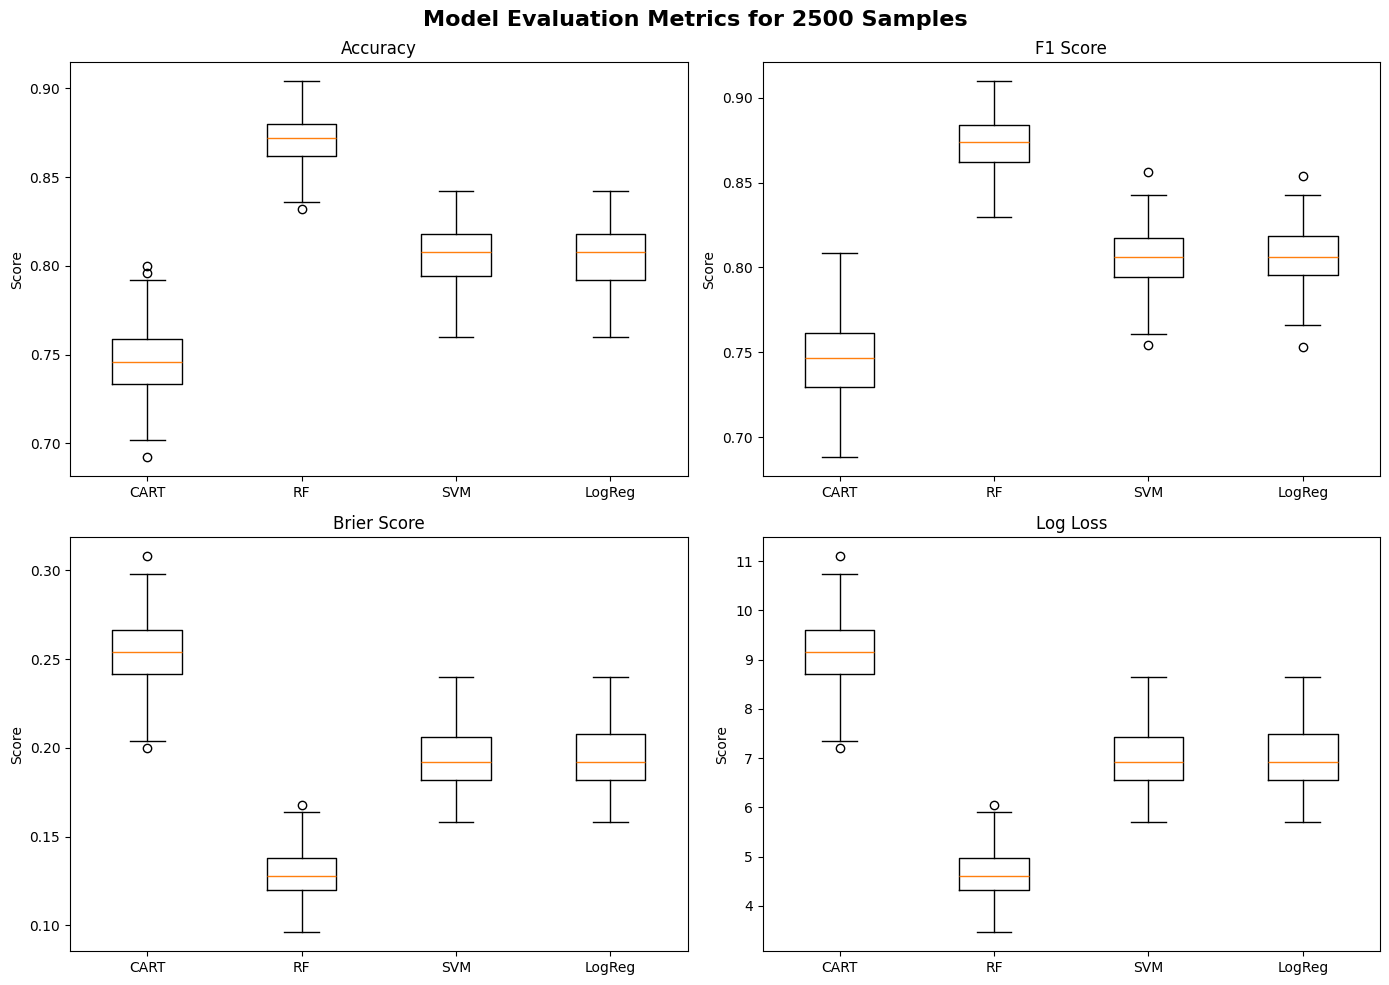

NEMENYI POST-HOC TEST (Accuracy)

P-values (Lower Triangular):
        CART   RF       SVM    LogReg
CART     1.0  0.0  0.000000  0.000000
RF       0.0  1.0  0.000000  0.000000
SVM      0.0  0.0  1.000000  0.999941
LogReg   0.0  0.0  0.999941  1.000000

Symmetric P-value Matrix:
        CART   RF       SVM    LogReg
CART     1.0  0.0  0.000000  0.000000
RF       0.0  1.0  0.000000  0.000000
SVM      0.0  0.0  1.000000  0.999941
LogReg   0.0  0.0  0.999941  1.000000
CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)


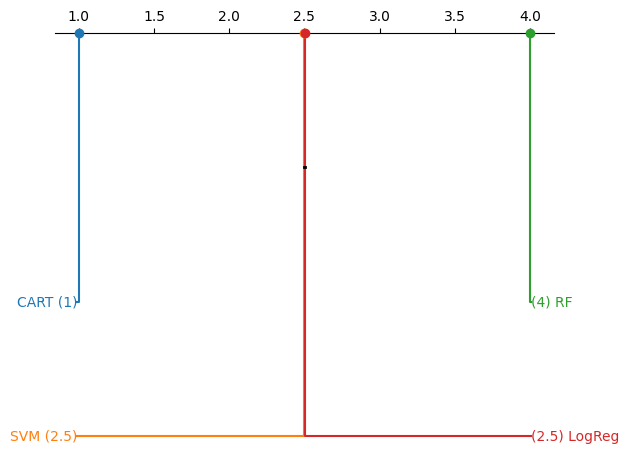

In [44]:
_2500_results_cart = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_cart_2500.csv") 
_2500_results_rf = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_rf_2500.csv")
_2500_results_SVM = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_SVM_2500.csv")
_2500_results_logreg = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_logreg_2500.csv")


labels = ['CART', 'RF', 'SVM', 'LogReg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))


_2500_acc_cart = _2500_results_cart['accuracy'].to_numpy()
_2500_acc_rf = _2500_results_rf['accuracy'].to_numpy()
_2500_acc_SVM = _2500_results_SVM['accuracy'].to_numpy()
_2500_acc_logreg = _2500_results_logreg['accuracy'].to_numpy()


axs[0, 0].boxplot([_2500_acc_cart, _2500_acc_rf, _2500_acc_SVM, _2500_acc_logreg], tick_labels=labels)
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Score')


_2500_f1_cart = _2500_results_cart['f1_score'].to_numpy()
_2500_f1_rf = _2500_results_rf['f1_score'].to_numpy()
_2500_f1_SVM = _2500_results_SVM['f1_score'].to_numpy()
_2500_f1_logreg = _2500_results_logreg['f1_score'].to_numpy()

axs[0, 1].boxplot([_2500_f1_cart, _2500_f1_rf, _2500_f1_SVM, _2500_f1_logreg], tick_labels=labels)
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_ylabel('Score')


_2500_brier_cart = _2500_results_cart['brier_score'].to_numpy()
_2500_brier_rf = _2500_results_rf['brier_score'].to_numpy()
_2500_brier_SVM = _2500_results_SVM['brier_score'].to_numpy()
_2500_brier_logreg = _2500_results_logreg['brier_score'].to_numpy()

axs[1, 0].boxplot([_2500_brier_cart, _2500_brier_rf, _2500_brier_SVM, _2500_brier_logreg], tick_labels=labels)
axs[1, 0].set_title('Brier Score')
axs[1, 0].set_ylabel('Score')


_2500_log_loss_cart = _2500_results_cart['log_loss'].to_numpy()
_2500_log_loss_rf = _2500_results_rf['log_loss'].to_numpy()
_2500_log_loss_SVM = _2500_results_SVM['log_loss'].to_numpy()
_2500_log_loss_logreg = _2500_results_logreg['log_loss'].to_numpy()

axs[1, 1].boxplot([_2500_log_loss_cart, _2500_log_loss_rf, _2500_log_loss_SVM, _2500_log_loss_logreg], tick_labels=labels)
axs[1, 1].set_title('Log Loss')
axs[1, 1].set_ylabel('Score')


plt.suptitle('Model Evaluation Metrics for 2500 Samples', fontsize=16, fontweight='bold')
plt.tight_layout()  
plt.show()

accuracy = pd.DataFrame({'CART': _2500_acc_cart, 'RF': _2500_acc_rf, 'SVM': _2500_acc_SVM, 'LogReg':_2500_acc_logreg})
print("=" * 70)
print("NEMENYI POST-HOC TEST (Accuracy)")
print("=" * 70)

# Use built-in Nemenyi test from scikit_posthocs
p_nemenyi = sp.posthoc_nemenyi_friedman(accuracy)

print("\nP-values (Lower Triangular):")
print(p_nemenyi.round(6))

# Create symmetric version for downstream analysis
p_nemenyi_sym = np.array(p_nemenyi, copy=True, dtype=float)
i_lower = np.tril_indices(p_nemenyi_sym.shape[0], -1)
p_nemenyi_sym[i_lower[1], i_lower[0]] = p_nemenyi_sym[i_lower]
np.fill_diagonal(p_nemenyi_sym, 1)

print("\nSymmetric P-value Matrix:")
print(pd.DataFrame(np.round(p_nemenyi_sym, 6), 
                   index=accuracy.columns, 
                   columns=accuracy.columns))


# Compute average ranks for CD diagram
ranks = np.array([rankdata(row) for row in accuracy.values])
mean_ranks = ranks.mean(axis=0)

# Convert mean_ranks to Series with proper index to match p-value matrix
mean_ranks_series = pd.Series(mean_ranks, index=accuracy.columns)

# Create CD diagram
print("=" * 70)
print("CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)")
print("=" * 70)

# Create symmetric p-value DataFrame for CD diagram
p_nemenyi_for_cd = pd.DataFrame(p_nemenyi_sym, 
                                 index=accuracy.columns, 
                                 columns=accuracy.columns)

# Use scikit_posthocs critical_difference_diagram with p-value matrix
sp.critical_difference_diagram(mean_ranks_series, p_nemenyi_for_cd, alpha=0.05)
plt.tight_layout()
plt.show()

#### 1000

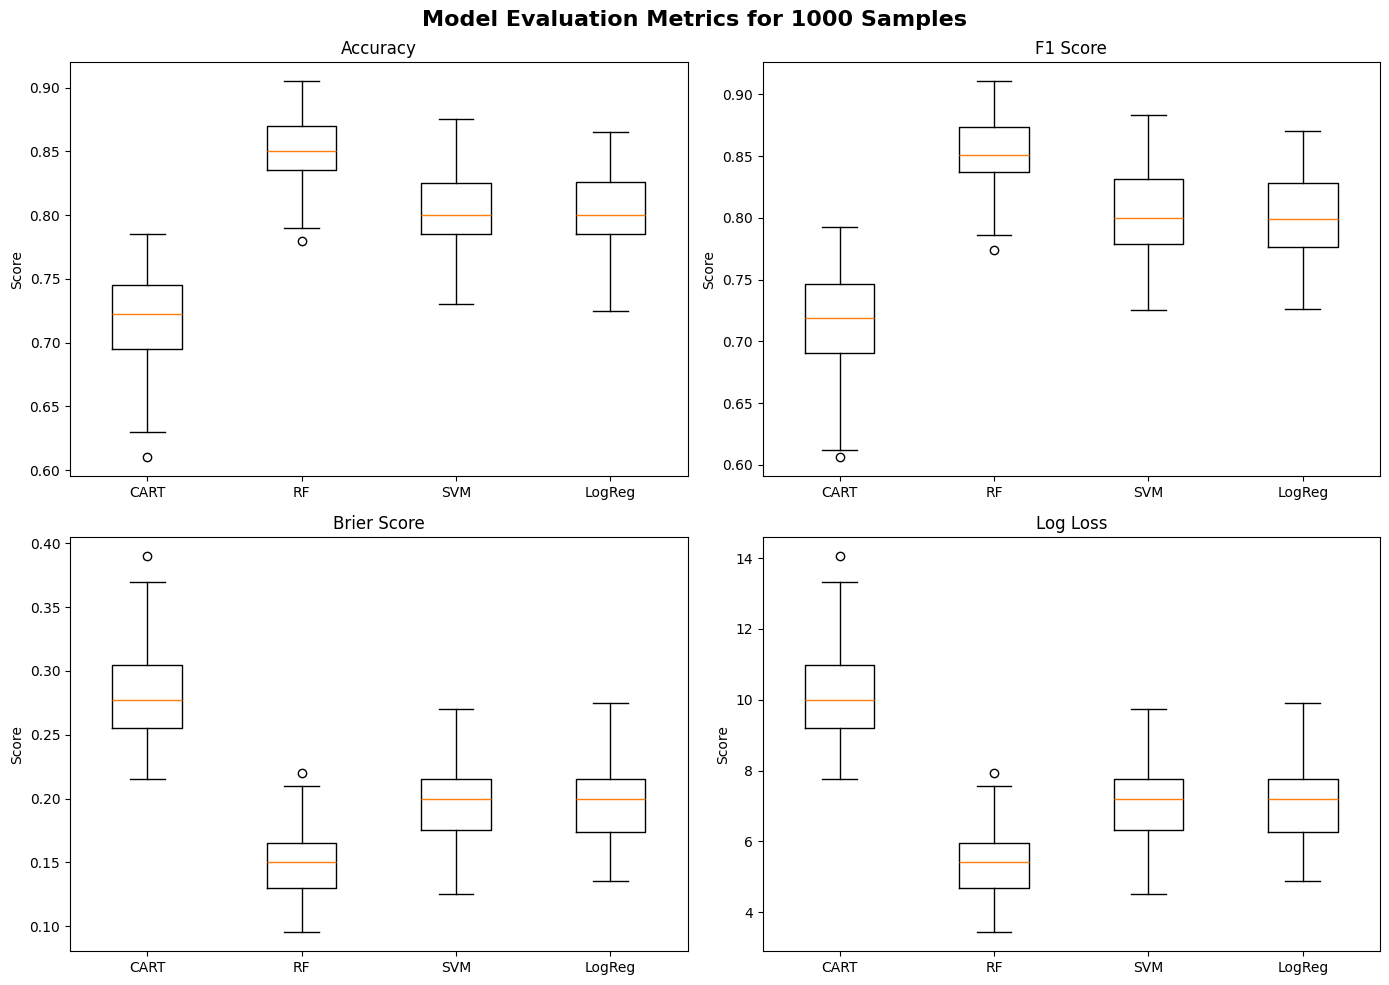

NEMENYI POST-HOC TEST (Accuracy)

P-values (Lower Triangular):
        CART   RF       SVM    LogReg
CART     1.0  0.0  0.000000  0.000000
RF       0.0  1.0  0.000000  0.000000
SVM      0.0  0.0  1.000000  0.922465
LogReg   0.0  0.0  0.922465  1.000000

Symmetric P-value Matrix:
        CART   RF       SVM    LogReg
CART     1.0  0.0  0.000000  0.000000
RF       0.0  1.0  0.000000  0.000000
SVM      0.0  0.0  1.000000  0.922465
LogReg   0.0  0.0  0.922465  1.000000
CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)


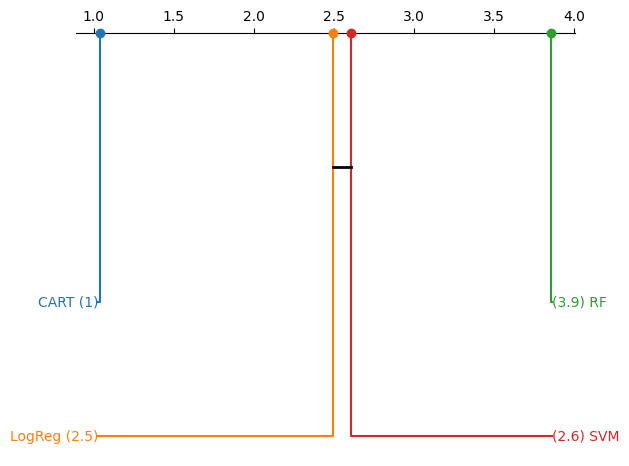

In [46]:
_1000_results_cart = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_cart_1000.csv") 
_1000_results_rf = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_rf_1000.csv")
_1000_results_SVM = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_SVM_1000.csv")
_1000_results_logreg = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_logreg_1000.csv")


labels = ['CART', 'RF', 'SVM', 'LogReg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))


_1000_acc_cart = _1000_results_cart['accuracy'].to_numpy()
_1000_acc_rf = _1000_results_rf['accuracy'].to_numpy()
_1000_acc_SVM = _1000_results_SVM['accuracy'].to_numpy()
_1000_acc_logreg = _1000_results_logreg['accuracy'].to_numpy()


axs[0, 0].boxplot([_1000_acc_cart, _1000_acc_rf, _1000_acc_SVM, _1000_acc_logreg], tick_labels=labels)
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Score')


_1000_f1_cart = _1000_results_cart['f1_score'].to_numpy()
_1000_f1_rf = _1000_results_rf['f1_score'].to_numpy()
_1000_f1_SVM = _1000_results_SVM['f1_score'].to_numpy()
_1000_f1_logreg = _1000_results_logreg['f1_score'].to_numpy()

axs[0, 1].boxplot([_1000_f1_cart, _1000_f1_rf, _1000_f1_SVM, _1000_f1_logreg], tick_labels=labels)
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_ylabel('Score')


_1000_brier_cart = _1000_results_cart['brier_score'].to_numpy()
_1000_brier_rf = _1000_results_rf['brier_score'].to_numpy()
_1000_brier_SVM = _1000_results_SVM['brier_score'].to_numpy()
_1000_brier_logreg = _1000_results_logreg['brier_score'].to_numpy()

axs[1, 0].boxplot([_1000_brier_cart, _1000_brier_rf, _1000_brier_SVM, _1000_brier_logreg], tick_labels=labels)
axs[1, 0].set_title('Brier Score')
axs[1, 0].set_ylabel('Score')


_1000_log_loss_cart = _1000_results_cart['log_loss'].to_numpy()
_1000_log_loss_rf = _1000_results_rf['log_loss'].to_numpy()
_1000_log_loss_SVM = _1000_results_SVM['log_loss'].to_numpy()
_1000_log_loss_logreg = _1000_results_logreg['log_loss'].to_numpy()

axs[1, 1].boxplot([_1000_log_loss_cart, _1000_log_loss_rf, _1000_log_loss_SVM, _1000_log_loss_logreg], tick_labels=labels)
axs[1, 1].set_title('Log Loss')
axs[1, 1].set_ylabel('Score')


plt.suptitle('Model Evaluation Metrics for 1000 Samples', fontsize=16, fontweight='bold')
plt.tight_layout()  
plt.show()

accuracy = pd.DataFrame({'CART': _1000_acc_cart, 'RF': _1000_acc_rf, 'SVM': _1000_acc_SVM, 'LogReg':_1000_acc_logreg})
print("=" * 70)
print("NEMENYI POST-HOC TEST (Accuracy)")
print("=" * 70)

# Use built-in Nemenyi test from scikit_posthocs
p_nemenyi = sp.posthoc_nemenyi_friedman(accuracy)

print("\nP-values (Lower Triangular):")
print(p_nemenyi.round(6))

# Create symmetric version for downstream analysis
p_nemenyi_sym = np.array(p_nemenyi, copy=True, dtype=float)
i_lower = np.tril_indices(p_nemenyi_sym.shape[0], -1)
p_nemenyi_sym[i_lower[1], i_lower[0]] = p_nemenyi_sym[i_lower]
np.fill_diagonal(p_nemenyi_sym, 1)

print("\nSymmetric P-value Matrix:")
print(pd.DataFrame(np.round(p_nemenyi_sym, 6), 
                   index=accuracy.columns, 
                   columns=accuracy.columns))


# Compute average ranks for CD diagram
ranks = np.array([rankdata(row) for row in accuracy.values])
mean_ranks = ranks.mean(axis=0)

# Convert mean_ranks to Series with proper index to match p-value matrix
mean_ranks_series = pd.Series(mean_ranks, index=accuracy.columns)

# Create CD diagram
print("=" * 70)
print("CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)")
print("=" * 70)

# Create symmetric p-value DataFrame for CD diagram
p_nemenyi_for_cd = pd.DataFrame(p_nemenyi_sym, 
                                 index=accuracy.columns, 
                                 columns=accuracy.columns)

# Use scikit_posthocs critical_difference_diagram with p-value matrix
sp.critical_difference_diagram(mean_ranks_series, p_nemenyi_for_cd, alpha=0.05)
plt.tight_layout()
plt.show()

#### 500

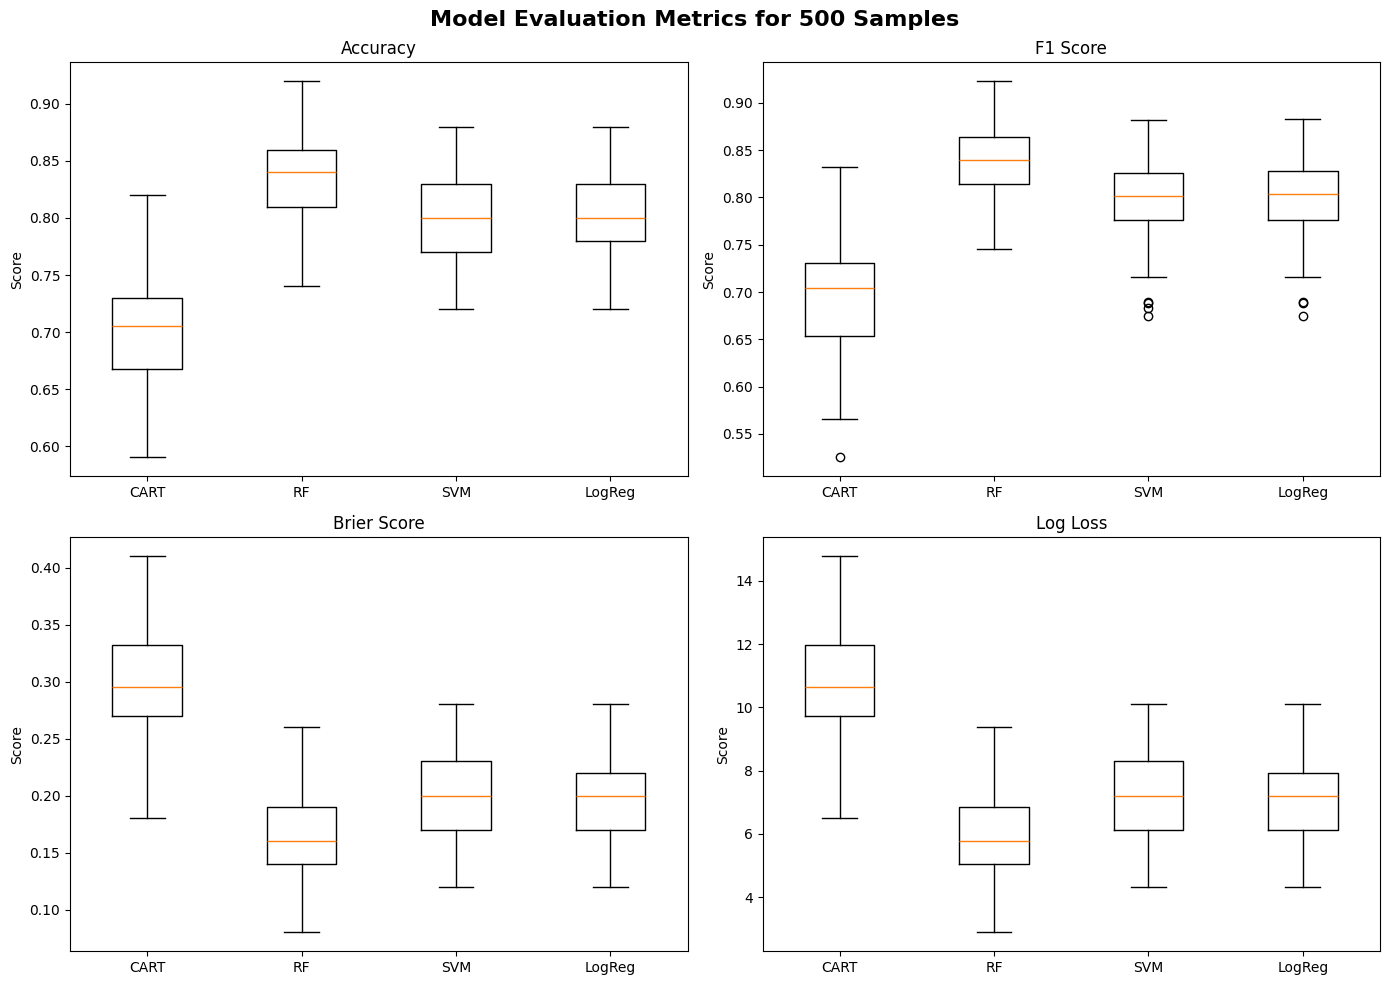

NEMENYI POST-HOC TEST (Accuracy)

P-values (Lower Triangular):
        CART        RF       SVM    LogReg
CART     1.0  0.000000  0.000000  0.000000
RF       0.0  1.000000  0.000002  0.000002
SVM      0.0  0.000002  1.000000  0.999993
LogReg   0.0  0.000002  0.999993  1.000000

Symmetric P-value Matrix:
        CART        RF       SVM    LogReg
CART     1.0  0.000000  0.000000  0.000000
RF       0.0  1.000000  0.000002  0.000002
SVM      0.0  0.000002  1.000000  0.999993
LogReg   0.0  0.000002  0.999993  1.000000
CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)


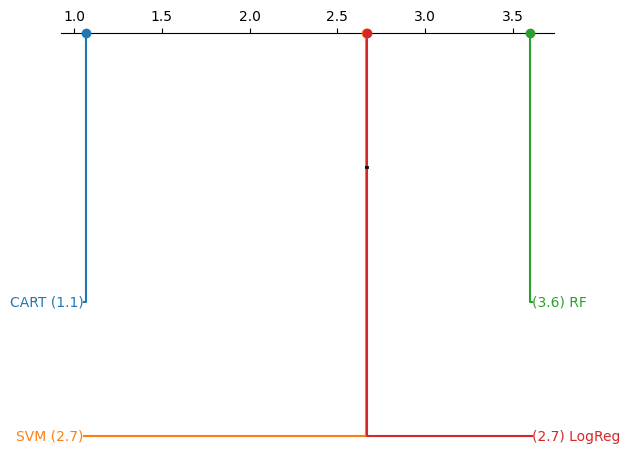

In [47]:
_500_results_cart = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_cart_500_500.csv") 
_500_results_rf = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_rf_500_500.csv")
_500_results_SVM = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_SVM_500_500.csv")
_500_results_logreg = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_logreg_500_500.csv")


labels = ['CART', 'RF', 'SVM', 'LogReg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))


_500_acc_cart = _500_results_cart['accuracy'].to_numpy()
_500_acc_rf = _500_results_rf['accuracy'].to_numpy()
_500_acc_SVM = _500_results_SVM['accuracy'].to_numpy()
_500_acc_logreg = _500_results_logreg['accuracy'].to_numpy()


axs[0, 0].boxplot([_500_acc_cart, _500_acc_rf, _500_acc_SVM, _500_acc_logreg], tick_labels=labels)
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Score')


_500_f1_cart = _500_results_cart['f1_score'].to_numpy()
_500_f1_rf = _500_results_rf['f1_score'].to_numpy()
_500_f1_SVM = _500_results_SVM['f1_score'].to_numpy()
_500_f1_logreg = _500_results_logreg['f1_score'].to_numpy()

axs[0, 1].boxplot([_500_f1_cart, _500_f1_rf, _500_f1_SVM, _500_f1_logreg], tick_labels=labels)
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_ylabel('Score')


_500_brier_cart = _500_results_cart['brier_score'].to_numpy()
_500_brier_rf = _500_results_rf['brier_score'].to_numpy()
_500_brier_SVM = _500_results_SVM['brier_score'].to_numpy()
_500_brier_logreg = _500_results_logreg['brier_score'].to_numpy()

axs[1, 0].boxplot([_500_brier_cart, _500_brier_rf, _500_brier_SVM, _500_brier_logreg], tick_labels=labels)
axs[1, 0].set_title('Brier Score')
axs[1, 0].set_ylabel('Score')


_500_log_loss_cart = _500_results_cart['log_loss'].to_numpy()
_500_log_loss_rf = _500_results_rf['log_loss'].to_numpy()
_500_log_loss_SVM = _500_results_SVM['log_loss'].to_numpy()
_500_log_loss_logreg = _500_results_logreg['log_loss'].to_numpy()

axs[1, 1].boxplot([_500_log_loss_cart, _500_log_loss_rf, _500_log_loss_SVM, _500_log_loss_logreg], tick_labels=labels)
axs[1, 1].set_title('Log Loss')
axs[1, 1].set_ylabel('Score')


plt.suptitle('Model Evaluation Metrics for 500 Samples', fontsize=16, fontweight='bold')
plt.tight_layout()  
plt.show()

accuracy = pd.DataFrame({'CART': _500_acc_cart, 'RF': _500_acc_rf, 'SVM': _500_acc_SVM, 'LogReg':_500_acc_logreg})
print("=" * 70)
print("NEMENYI POST-HOC TEST (Accuracy)")
print("=" * 70)

# Use built-in Nemenyi test from scikit_posthocs
p_nemenyi = sp.posthoc_nemenyi_friedman(accuracy)

print("\nP-values (Lower Triangular):")
print(p_nemenyi.round(6))

# Create symmetric version for downstream analysis
p_nemenyi_sym = np.array(p_nemenyi, copy=True, dtype=float)
i_lower = np.tril_indices(p_nemenyi_sym.shape[0], -1)
p_nemenyi_sym[i_lower[1], i_lower[0]] = p_nemenyi_sym[i_lower]
np.fill_diagonal(p_nemenyi_sym, 1)

print("\nSymmetric P-value Matrix:")
print(pd.DataFrame(np.round(p_nemenyi_sym, 6), 
                   index=accuracy.columns, 
                   columns=accuracy.columns))


# Compute average ranks for CD diagram
ranks = np.array([rankdata(row) for row in accuracy.values])
mean_ranks = ranks.mean(axis=0)

# Convert mean_ranks to Series with proper index to match p-value matrix
mean_ranks_series = pd.Series(mean_ranks, index=accuracy.columns)

# Create CD diagram
print("=" * 70)
print("CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)")
print("=" * 70)

# Create symmetric p-value DataFrame for CD diagram
p_nemenyi_for_cd = pd.DataFrame(p_nemenyi_sym, 
                                 index=accuracy.columns, 
                                 columns=accuracy.columns)

# Use scikit_posthocs critical_difference_diagram with p-value matrix
sp.critical_difference_diagram(mean_ranks_series, p_nemenyi_for_cd, alpha=0.05)
plt.tight_layout()
plt.show()

#### 100

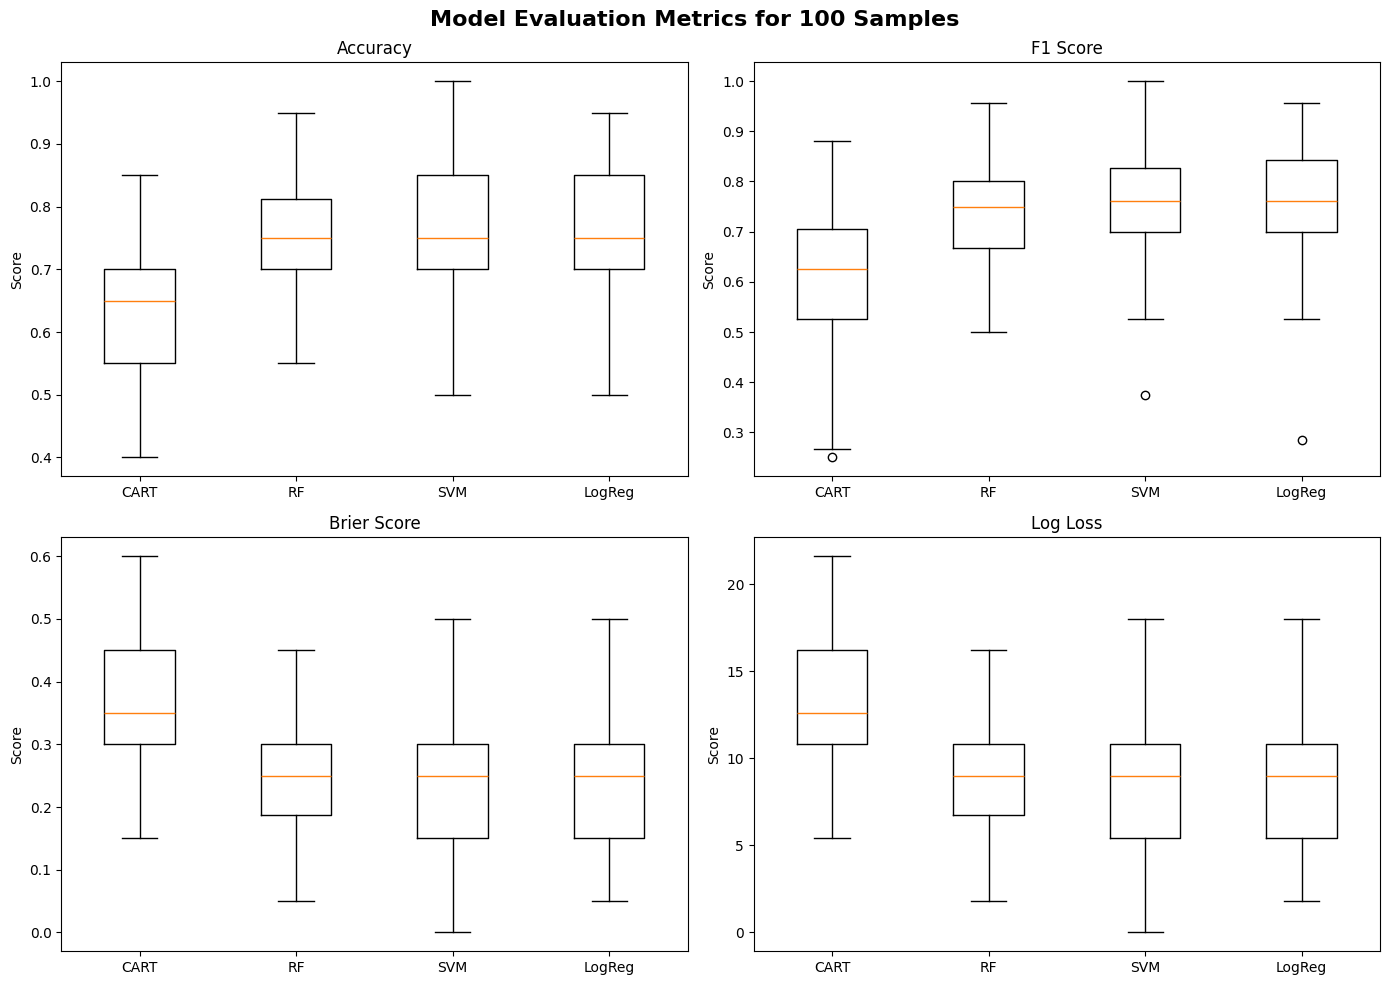

NEMENYI POST-HOC TEST (Accuracy)

P-values (Lower Triangular):
        CART        RF       SVM    LogReg
CART     1.0  0.000000  0.000000  0.000000
RF       0.0  1.000000  0.922465  0.999084
SVM      0.0  0.922465  1.000000  0.960688
LogReg   0.0  0.999084  0.960688  1.000000

Symmetric P-value Matrix:
        CART        RF       SVM    LogReg
CART     1.0  0.000000  0.000000  0.000000
RF       0.0  1.000000  0.922465  0.999084
SVM      0.0  0.922465  1.000000  0.960688
LogReg   0.0  0.999084  0.960688  1.000000
CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)


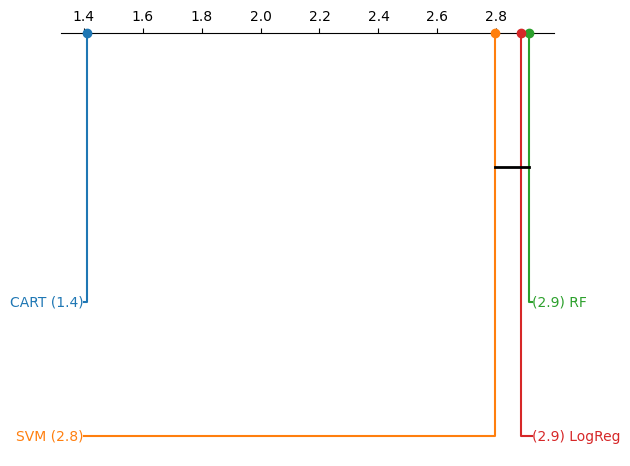

In [49]:
_100_results_cart = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_cart_100.csv") 
_100_results_rf = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_rf_100.csv")
_100_results_SVM = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_SVM_100.csv")
_100_results_logreg = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_balanced/results_logreg_100.csv")


labels = ['CART', 'RF', 'SVM', 'LogReg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))


_100_acc_cart = _100_results_cart['accuracy'].to_numpy()
_100_acc_rf = _100_results_rf['accuracy'].to_numpy()
_100_acc_SVM = _100_results_SVM['accuracy'].to_numpy()
_100_acc_logreg = _100_results_logreg['accuracy'].to_numpy()


axs[0, 0].boxplot([_100_acc_cart, _100_acc_rf, _100_acc_SVM, _100_acc_logreg], tick_labels=labels)
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Score')


_100_f1_cart = _100_results_cart['f1_score'].to_numpy()
_100_f1_rf = _100_results_rf['f1_score'].to_numpy()
_100_f1_SVM = _100_results_SVM['f1_score'].to_numpy()
_100_f1_logreg = _100_results_logreg['f1_score'].to_numpy()

axs[0, 1].boxplot([_100_f1_cart, _100_f1_rf, _100_f1_SVM, _100_f1_logreg], tick_labels=labels)
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_ylabel('Score')


_100_brier_cart = _100_results_cart['brier_score'].to_numpy()
_100_brier_rf = _100_results_rf['brier_score'].to_numpy()
_100_brier_SVM = _100_results_SVM['brier_score'].to_numpy()
_100_brier_logreg = _100_results_logreg['brier_score'].to_numpy()

axs[1, 0].boxplot([_100_brier_cart, _100_brier_rf, _100_brier_SVM, _100_brier_logreg], tick_labels=labels)
axs[1, 0].set_title('Brier Score')
axs[1, 0].set_ylabel('Score')


_100_log_loss_cart = _100_results_cart['log_loss'].to_numpy()
_100_log_loss_rf = _100_results_rf['log_loss'].to_numpy()
_100_log_loss_SVM = _100_results_SVM['log_loss'].to_numpy()
_100_log_loss_logreg = _100_results_logreg['log_loss'].to_numpy()

axs[1, 1].boxplot([_100_log_loss_cart, _100_log_loss_rf, _100_log_loss_SVM, _100_log_loss_logreg], tick_labels=labels)
axs[1, 1].set_title('Log Loss')
axs[1, 1].set_ylabel('Score')


plt.suptitle('Model Evaluation Metrics for 100 Samples', fontsize=16, fontweight='bold')
plt.tight_layout()  
plt.show()

accuracy = pd.DataFrame({'CART': _100_acc_cart, 'RF': _100_acc_rf, 'SVM': _100_acc_SVM, 'LogReg':_100_acc_logreg})
print("=" * 70)
print("NEMENYI POST-HOC TEST (Accuracy)")
print("=" * 70)

# Use built-in Nemenyi test from scikit_posthocs
p_nemenyi = sp.posthoc_nemenyi_friedman(accuracy)

print("\nP-values (Lower Triangular):")
print(p_nemenyi.round(6))

# Create symmetric version for downstream analysis
p_nemenyi_sym = np.array(p_nemenyi, copy=True, dtype=float)
i_lower = np.tril_indices(p_nemenyi_sym.shape[0], -1)
p_nemenyi_sym[i_lower[1], i_lower[0]] = p_nemenyi_sym[i_lower]
np.fill_diagonal(p_nemenyi_sym, 1)

print("\nSymmetric P-value Matrix:")
print(pd.DataFrame(np.round(p_nemenyi_sym, 6), 
                   index=accuracy.columns, 
                   columns=accuracy.columns))


# Compute average ranks for CD diagram
ranks = np.array([rankdata(row) for row in accuracy.values])
mean_ranks = ranks.mean(axis=0)

# Convert mean_ranks to Series with proper index to match p-value matrix
mean_ranks_series = pd.Series(mean_ranks, index=accuracy.columns)

# Create CD diagram
print("=" * 70)
print("CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)")
print("=" * 70)

# Create symmetric p-value DataFrame for CD diagram
p_nemenyi_for_cd = pd.DataFrame(p_nemenyi_sym, 
                                 index=accuracy.columns, 
                                 columns=accuracy.columns)

# Use scikit_posthocs critical_difference_diagram with p-value matrix
sp.critical_difference_diagram(mean_ranks_series, p_nemenyi_for_cd, alpha=0.05)
plt.tight_layout()
plt.show()

# Part 2 - Themes
You will be allocated one of the three themes and should perform ***all*** tasks as described in this theme.

### Theme 1 - Imbalance
Use the Cats and Dogs dataset.

Investigate the effects of imbalance on PART 1 - where you create the imbalance. Try with different train, calibration and test sizes. 

Does the model ranking change?

In [ ]:
# First the cats and dogs data...
import pandas as pd 

PATHIM = "C://Users//wwide//MVE441//cnd_large//images.csv"
PATHLB = "C://Users//wwide//MVE441//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels['label'].unique()}")

In [ ]:
images = np.array(images)
labels = np.array(labels).ravel()

X = images
y = labels

X_images = X.reshape(-1, 64, 64)
X_cropped = X_images[:, 6:-6, 6:-6]

print("Old dimension:", (64, 64))
print("New dimensions:", X_cropped.shape[1:]) 

X_final = X_cropped.reshape(X_cropped.shape[0], -1)

print("New number of features per image:", X_final.shape[1])

In [ ]:
X_cats = X_final[0:5000]
X_dogs = X_final[5000:10000]
y_cats = labels[0:5000]
y_dogs = labels[5000:10000]

In [ ]:
from sklearn.model_selection import KFold, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score, log_loss, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

In [1]:
cat_size = 100
dog_size = int(cat_size * 0.25)

X_cats_data = X_cats[np.random.choice(X_cats.shape[0], size = cat_size, replace = False)]
X_dogs_data = X_dogs[np.random.choice(X_dogs.shape[0], size = dog_size, replace = False)]

X = np.concatenate([X_cats_data, X_dogs_data])
y = np.concatenate([np.zeros(cat_size), np.ones(dog_size)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

NameError: name 'X_cats' is not defined

### Unbalanced 10 repeated 10-fold CV 

With the same functions and GridSearch parameters as in Part 1

In [ ]:
R = 10
K = 10

results_cart_list = []
results_rf_list = []
results_SVM_list = []
results_logreg_list = []

for r in range(R):    
    X = X_train.copy()
    y = y_train.copy()

    kf = StratifiedKFold(n_splits=K, shuffle=True)
     
    for train_index, test_index in kf.split(X, y):
        X_train, X_cal = X[train_index], X[test_index]
        y_train, y_cal = y[train_index], y[test_index]

        pca = PCA(n_components=40, svd_solver= 'full')
        pca_train = pca.fit_transform(X_train)
        pca_val = pca.transform(X_cal)

        results_cart = grid_search_cart(pca_train, y_train, pca_val, y_cal)
        results_cart["repeat"] = r
        results_cart["fold"] = len(results_cart_list) % K
        results_cart_list.append(results_cart)

        results_rf = grid_search_rf(pca_train, y_train, pca_val, y_cal)
        results_rf["repeat"] = r
        results_rf["fold"] = len(results_rf_list) % K
        results_rf_list.append(results_rf)

        results_SVM = grid_search_svm(pca_train, y_train, pca_val, y_cal)
        results_SVM["repeat"] = r
        results_SVM["fold"] = len(results_SVM_list) % K
        results_SVM_list.append(results_SVM)

        results_logreg = grid_search_logreg(pca_train, y_train, pca_val, y_cal)
        results_logreg["repeat"] = r
        results_logreg["fold"] = len(results_logreg_list) % K
        results_logreg_list.append(results_logreg)

    df_cart = pd.DataFrame(results_cart_list)
    df_cart.to_csv("results_cart_unbalanced.csv", index=False)

    df_rf = pd.DataFrame(results_rf_list)
    df_rf.to_csv("results_rf_unbalanced.csv", index=False)

    df_SVM = pd.DataFrame(results_SVM_list)
    df_SVM.to_csv("results_SVM_unbalanced.csv", index=False)

    df_logreg = pd.DataFrame(results_logreg_list)
    df_logreg.to_csv("results_logreg_unbalanced.csv", index=False)

## Unbalanced Model comparisson

In [ ]:
# Load results from CSV files

results_cart_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_cart_unbalanced_1000.csv") 
results_rf_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_rf_unbalanced_1000.csv")
results_SVM_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_SVM_unbalanced_1000.csv")
results_logreg_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_logreg_unbalanced_1000.csv")

frequency_cart_u = Counter(zip(results_cart_u["criterion"], results_cart_u["min_samples_leaf"], results_cart_u["min_samples_split"])).most_common(5)
frequency_rf_u = Counter(zip(results_rf_u["n_estimators"], results_rf_u["criterion"], results_rf_u["max_features"], results_rf_u["min_samples_leaf"], results_rf_u["min_samples_split"])).most_common(5)
frequency_logreg_u = Counter(results_logreg_u["C"]).most_common(5)
frequency_SVM_u = Counter(results_SVM_u["C"]).most_common(5)

print("Result CART:",dict(frequency_cart_u))
print("Result RF:",dict(frequency_rf_u))
print("Result LOGREG:",dict(frequency_logreg_u))
print("Result SVM:",dict(frequency_SVM_u))


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_cart_unbalanced_100.csv'

### Results

In [ ]:
PATHIM = "C://Users//wwide//MVE441//cnd_large//images.csv"
PATHLB = "C://Users//wwide//MVE441//cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)
labels = labels.rename(columns={"0":"label"})
images = np.array(images)
labels = np.array(labels).ravel()

X = images
y = labels

X_images = X.reshape(-1, 64, 64)
X_cropped = X_images[:, 6:-6, 6:-6]
X_final = X_cropped.reshape(X_cropped.shape[0], -1)

X_cats = X_final[0:5000]
X_dogs = X_final[5000:10000]
y_cats = labels[0:5000]
y_dogs = labels[5000:10000]

#### 5000 unbalanced
Result CART: {('gini', 15, 2): 28, ('gini', 15, 14): 18, ('gini', 15, 6): 14, ('entropy', 15, 14): 13, ('entropy', 15, 6): 9}

Result RF: {(200, 'gini', 'sqrt', 1, 2): 44, (200, 'gini', 'sqrt', 1, 10): 20, (100, 'gini', 'sqrt', 1, 2): 19, (100, 'gini', 'sqrt', 1, 10): 14, (200, 'gini', 'log2', 1, 2): 2}

Result LOGREG: {0.001: 99, 0.01: 1}

Result SVM: {0.1: 67, 1.0: 28, 10.0: 5}

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
cat_size = 5000
dog_size = int(cat_size * 0.25)
X_dogs_sample = X_dogs[np.random.choice(X_dogs.shape[0], size = cat_size, replace = False)]
X_cats_sample = X_cats[np.random.choice(X_cats.shape[0], size = dog_size, replace = False)]
X = np.concatenate([X_cats_sample, X_dogs_sample])
y = np.concatenate([np.zeros(dog_size), np.ones(cat_size)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

CART_5000 = DecisionTreeClassifier(splitter="best", criterion="gini", max_features=None, min_samples_leaf=15, min_samples_split=2)
RF_5000 = RandomForestClassifier(n_estimators=200, criterion="gini", max_features="sqrt", min_samples_leaf=1, min_samples_split=2)
LOGREG_5000 = LogisticRegression(solver = "lbfgs", penalty="l2", max_iter = 10000, C=0.001)
SVM_5000 = LinearSVC(C=0.1)

CART_5000.fit(X_train, y_train)
RF_5000.fit(X_train, y_train)
LOGREG_5000.fit(X_train, y_train)
SVM_5000.fit(X_train, y_train)

pred_cart_5000 = CART_5000.predict(X_test)
pred_rf_5000 = RF_5000.predict(X_test)
pred_logreg_5000 = LOGREG_5000.predict(X_test)
pred_SVM_5000 = SVM_5000.predict(X_test)

print("CART 5000 Accuracy:", accuracy_score(y_test, pred_cart_5000))
print("RF 5000 Accuracy:", accuracy_score(y_test, pred_rf_5000))
print("LOGREG 5000 Accuracy:", accuracy_score(y_test, pred_logreg_5000))
print("SVM 5000 Accuracy:", accuracy_score(y_test, pred_SVM_5000))

#### 2500 unbalanced

Result CART: {('gini', 15, 2): 20, ('gini', 15, 14): 13, ('entropy', 15, 2): 11, ('gini', 15, 6): 8, ('entropy', 15, 14): 8}

Result RF: {(200, 'gini', 'sqrt', 1, 2): 32, (100, 'gini', 'sqrt', 1, 2): 19, (100, 'gini', 'sqrt', 1, 10): 14, (200, 'gini', 'sqrt', 1, 10): 12, (200, 'gini', 'log2', 1, 2): 7}

Result LOGREG: {0.001: 99, 0.01: 1}

Result SVM: {0.1: 72, 1.0: 23, 10.0: 5}

In [ ]:
cat_size = 2500
dog_size = int(cat_size * 0.25)
X_dogs_sample = X_dogs[np.random.choice(X_dogs.shape[0], size = cat_size, replace = False)]
X_cats_sample = X_cats[np.random.choice(X_cats.shape[0], size = dog_size, replace = False)]
X = np.concatenate([X_cats_sample, X_dogs_sample])
y = np.concatenate([np.zeros(dog_size), np.ones(cat_size)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

CART_2500 = DecisionTreeClassifier(splitter="best", criterion="gini", max_features=None, min_samples_leaf=15, min_samples_split=2)
RF_2500 = RandomForestClassifier(n_estimators=200, criterion="gini", max_features="sqrt", min_samples_leaf=1, min_samples_split=2)
LOGREG_2500 = LogisticRegression(solver = "lbfgs", penalty="l2", max_iter = 10000, C=0.001)
SVM_2500 = LinearSVC(C=0.1)

CART_2500.fit(X_train, y_train)
RF_2500.fit(X_train, y_train)
LOGREG_2500.fit(X_train, y_train)
SVM_2500.fit(X_train, y_train)

pred_cart_2500 = CART_2500.predict(X_test)
pred_rf_2500 = RF_2500.predict(X_test)
pred_logreg_2500 = LOGREG_2500.predict(X_test)
pred_SVM_2500 = SVM_2500.predict(X_test)

print("CART 2500 Accuracy:", accuracy_score(y_test, pred_cart_2500))
print("RF 2500 Accuracy:", accuracy_score(y_test, pred_rf_2500))
print("LOGREG 2500 Accuracy:", accuracy_score(y_test, pred_logreg_2500))
print("SVM 2500 Accuracy:", accuracy_score(y_test, pred_SVM_2500))

#### 1000 unbalanced

Result CART: {('entropy', 15, 2): 17, ('entropy', 15, 6): 11, ('gini', 15, 2): 9, ('gini', 15, 14): 9, ('entropy', 7, 6): 8}

Result RF: {(200, 'gini', 'sqrt', 1, 2): 25, (100, 'gini', 'sqrt', 1, 2): 23, (100, 'gini', 'sqrt', 1, 10): 16, (200, 'gini', 'log2', 1, 2): 10, (200, 'gini', 'sqrt', 1, 10): 9}

Result LOGREG: {0.001: 96, 0.01: 4}

Result SVM: {0.1: 66, 1.0: 25, 10.0: 9}

In [ ]:
cat_size = 1000
dog_size = int(cat_size * 0.25)
X_dogs_sample = X_dogs[np.random.choice(X_dogs.shape[0], size = cat_size, replace = False)]
X_cats_sample = X_cats[np.random.choice(X_cats.shape[0], size = dog_size, replace = False)]
X = np.concatenate([X_cats_sample, X_dogs_sample])
y = np.concatenate([np.zeros(dog_size), np.ones(cat_size)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

CART_1000 = DecisionTreeClassifier(splitter="best", criterion="entropy", max_features=None, min_samples_leaf=15, min_samples_split=2)
RF_1000 = RandomForestClassifier(n_estimators=200, criterion="gini", max_features="sqrt", min_samples_leaf=1, min_samples_split=2)
LOGREG_1000 = LogisticRegression(solver = "lbfgs", penalty="l2", max_iter = 10000, C=0.001)
SVM_1000 = LinearSVC(C=0.1)

CART_1000.fit(X_train, y_train)
RF_1000.fit(X_train, y_train)
LOGREG_1000.fit(X_train, y_train)
SVM_1000.fit(X_train, y_train)

pred_cart_1000 = CART_1000.predict(X_test)
pred_rf_1000 = RF_1000.predict(X_test)
pred_logreg_1000 = LOGREG_1000.predict(X_test)
pred_SVM_1000 = SVM_1000.predict(X_test)

print("CART 1000 Accuracy:", accuracy_score(y_test, pred_cart_1000))
print("RF 1000 Accuracy:", accuracy_score(y_test, pred_rf_1000))
print("LOGREG 1000 Accuracy:", accuracy_score(y_test, pred_logreg_1000))
print("SVM 1000 Accuracy:", accuracy_score(y_test, pred_SVM_1000))

#### 500 unbalanced

Result CART: {('gini', 15, 2): 23, ('entropy', 15, 2): 11, ('gini', 15, 14): 8, ('entropy', 15, 6): 7, ('entropy', 15, 14): 7}

Result RF: {(100, 'gini', 'sqrt', 1, 2): 23, (200, 'gini', 'sqrt', 1, 2): 15, (100, 'gini', 'log2', 1, 2): 11, (200, 'gini', 'sqrt', 1, 10): 10, (100, 'gini', 'log2', 1, 10): 9}

Result LOGREG: {0.001: 86, 0.01: 7, 10.0: 5, 0.1: 2}

Result SVM: {0.1: 71, 1.0: 26, 10.0: 3}

In [ ]:
cat_size = 500
dog_size = int(cat_size * 0.25)
X_dogs_sample = X_dogs[np.random.choice(X_dogs.shape[0], size = cat_size, replace = False)]
X_cats_sample = X_cats[np.random.choice(X_cats.shape[0], size = dog_size, replace = False)]
X = np.concatenate([X_cats_sample, X_dogs_sample])
y = np.concatenate([np.zeros(dog_size), np.ones(cat_size)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

CART_500 = DecisionTreeClassifier(splitter="best", criterion="gini", max_features=None, min_samples_leaf=15, min_samples_split=2)
RF_500 = RandomForestClassifier(n_estimators=100, criterion="gini", max_features="sqrt", min_samples_leaf=1, min_samples_split=2)
LOGREG_500 = LogisticRegression(solver = "lbfgs", penalty="l2", max_iter = 10000, C=0.001)
SVM_500 = LinearSVC(C=0.1)

CART_500.fit(X_train, y_train)
RF_500.fit(X_train, y_train)
LOGREG_500.fit(X_train, y_train)
SVM_500.fit(X_train, y_train)

pred_cart_500 = CART_500.predict(X_test)
pred_rf_500 = RF_500.predict(X_test)
pred_logreg_500 = LOGREG_500.predict(X_test)
pred_SVM_500 = SVM_500.predict(X_test)

print("CART 500 Accuracy:", accuracy_score(y_test, pred_cart_500))
print("RF 500 Accuracy:", accuracy_score(y_test, pred_rf_500))
print("LOGREG 500 Accuracy:", accuracy_score(y_test, pred_logreg_500))
print("SVM 500 Accuracy:", accuracy_score(y_test, pred_SVM_500))

## Unbalanced Boxplots and critical difference diagram (Nemenyi Test)

#### 5000

C:\Users\wwide\AppData\Local\Temp\ipykernel_6528\2444126909.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, 0].boxplot([_5000_acc_cart, _5000_acc_rf, _5000_acc_SVM, _5000_acc_logreg], labels=labels)
C:\Users\wwide\AppData\Local\Temp\ipykernel_6528\2444126909.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, 1].boxplot([_5000_f1_cart, _5000_f1_rf, _5000_f1_SVM, _5000_f1_logreg], labels=labels)
C:\Users\wwide\AppData\Local\Temp\ipykernel_6528\2444126909.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1, 0].boxplot([_5000_brier_cart, _5000_brier_rf, _5000_brier_SVM, _5000_brier_logreg], lab

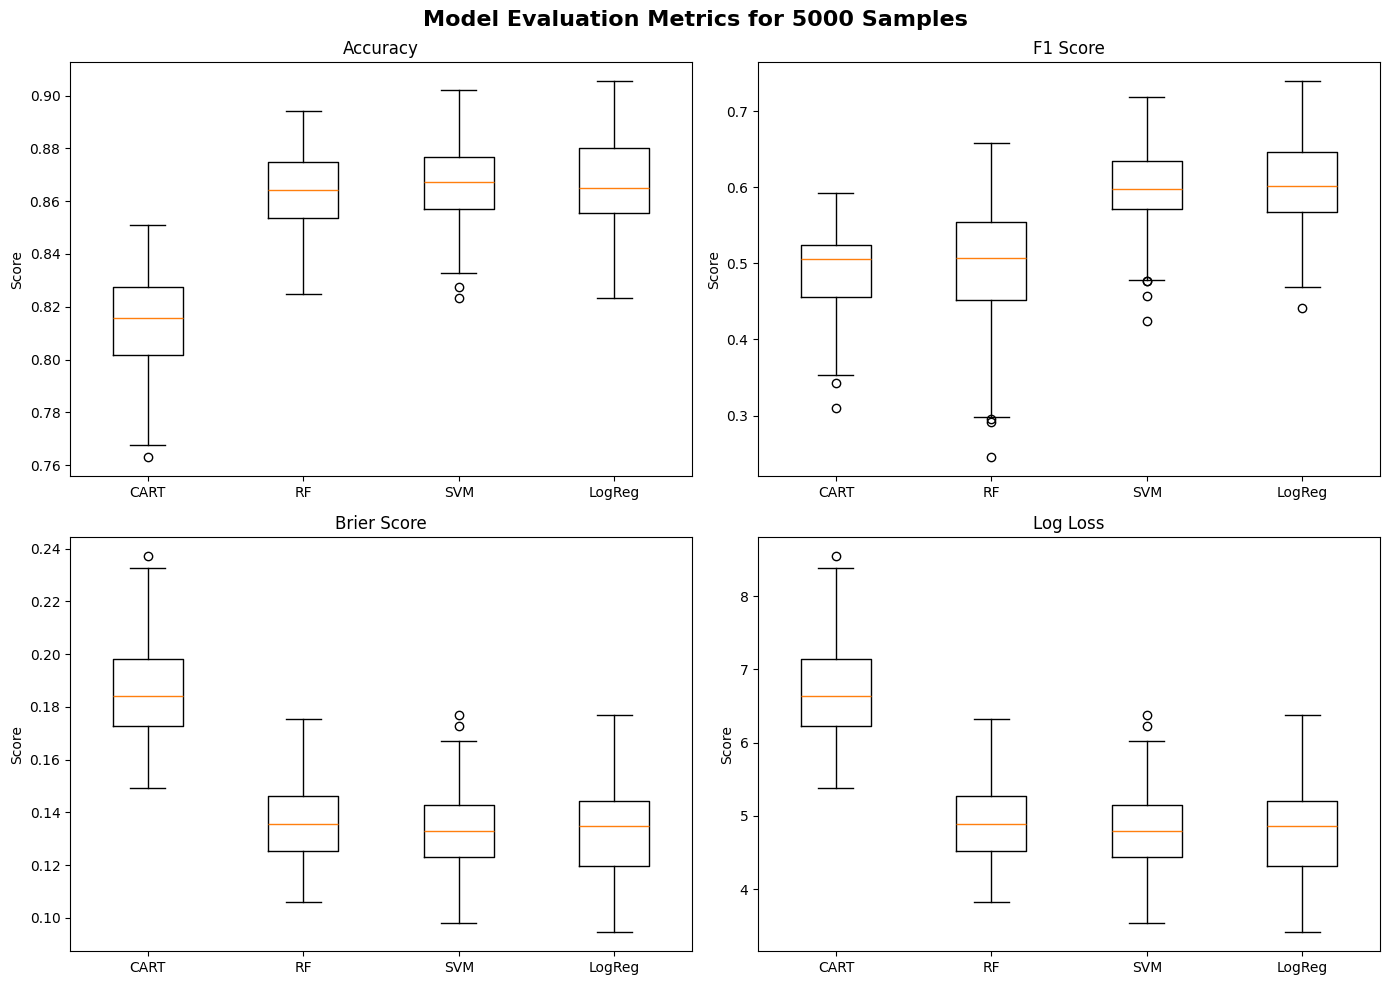

In [ ]:
_5000_results_cart_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_cart_unbalanced_5000.csv") 
_5000_results_rf_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_rf_unbalanced_5000.csv")
_5000_results_SVM_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_SVM_unbalanced_5000.csv")
_5000_results_logreg_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_logreg_unbalanced_5000.csv")


labels = ['CART', 'RF', 'SVM', 'LogReg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))


_5000_acc_cart = _5000_results_cart_u['accuracy'].to_numpy()
_5000_acc_rf = _5000_results_rf_u['accuracy'].to_numpy()
_5000_acc_SVM = _5000_results_SVM_u['accuracy'].to_numpy()
_5000_acc_logreg = _5000_results_logreg_u['accuracy'].to_numpy()


axs[0, 0].boxplot([_5000_acc_cart, _5000_acc_rf, _5000_acc_SVM, _5000_acc_logreg], tick_labels=labels)
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Score')


_5000_f1_cart = _5000_results_cart_u['f1_score'].to_numpy()
_5000_f1_rf = _5000_results_rf_u['f1_score'].to_numpy()
_5000_f1_SVM = _5000_results_SVM_u['f1_score'].to_numpy()
_5000_f1_logreg = _5000_results_logreg_u['f1_score'].to_numpy()

axs[0, 1].boxplot([_5000_f1_cart, _5000_f1_rf, _5000_f1_SVM, _5000_f1_logreg], tick_labels=labels)
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_ylabel('Score')


_5000_brier_cart = _5000_results_cart_u['brier_score'].to_numpy()
_5000_brier_rf = _5000_results_rf_u['brier_score'].to_numpy()
_5000_brier_SVM = _5000_results_SVM_u['brier_score'].to_numpy()
_5000_brier_logreg = _5000_results_logreg_u['brier_score'].to_numpy()

axs[1, 0].boxplot([_5000_brier_cart, _5000_brier_rf, _5000_brier_SVM, _5000_brier_logreg], tick_labels=labels)
axs[1, 0].set_title('Brier Score')
axs[1, 0].set_ylabel('Score')


_5000_log_loss_cart = _5000_results_cart_u['log_loss'].to_numpy()
_5000_log_loss_rf = _5000_results_rf_u['log_loss'].to_numpy()
_5000_log_loss_SVM = _5000_results_SVM_u['log_loss'].to_numpy()
_5000_log_loss_logreg = _5000_results_logreg_u['log_loss'].to_numpy()

axs[1, 1].boxplot([_5000_log_loss_cart, _5000_log_loss_rf, _5000_log_loss_SVM, _5000_log_loss_logreg], tick_labels=labels)
axs[1, 1].set_title('Log Loss')
axs[1, 1].set_ylabel('Score')


plt.suptitle('Model Evaluation Metrics for 5000 Samples', fontsize=16, fontweight='bold')
plt.tight_layout()  
plt.show()

# Nemenyi post-hoc test using scikit_posthocs
accuracy = pd.DataFrame({'CART': _5000_acc_cart, 'RF': _5000_acc_rf, 'SVM': _5000_acc_SVM, 'LogReg':_5000_acc_logreg})
print("=" * 70)
print("NEMENYI POST-HOC TEST (Accuracy)")
print("=" * 70)

# Use built-in Nemenyi test from scikit_posthocs
p_nemenyi = sp.posthoc_nemenyi_friedman(accuracy)

print("\nP-values (Lower Triangular):")
print(p_nemenyi.round(6))

# Create symmetric version for downstream analysis
p_nemenyi_sym = np.array(p_nemenyi, copy=True, dtype=float)
i_lower = np.tril_indices(p_nemenyi_sym.shape[0], -1)
p_nemenyi_sym[i_lower[1], i_lower[0]] = p_nemenyi_sym[i_lower]
np.fill_diagonal(p_nemenyi_sym, 1)

print("\nSymmetric P-value Matrix:")
print(pd.DataFrame(np.round(p_nemenyi_sym, 6), 
                   index=accuracy.columns, 
                   columns=accuracy.columns))


# Compute average ranks for CD diagram
ranks = np.array([rankdata(row) for row in accuracy.values])
mean_ranks = ranks.mean(axis=0)

# Convert mean_ranks to Series with proper index to match p-value matrix
mean_ranks_series = pd.Series(mean_ranks, index=accuracy.columns)

# Create CD diagram
print("=" * 70)
print("CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)")
print("=" * 70)

# Create symmetric p-value DataFrame for CD diagram
p_nemenyi_for_cd = pd.DataFrame(p_nemenyi_sym, 
                                 index=accuracy.columns, 
                                 columns=accuracy.columns)

# Use scikit_posthocs critical_difference_diagram with p-value matrix
sp.critical_difference_diagram(mean_ranks_series, p_nemenyi_for_cd, alpha=0.05)
plt.tight_layout()
plt.show()

In [ ]:
from itertools import combinations

def estimate_global_sigma(data):
    """
    Estimate a global standard deviation from pairwise differences.

    Parameters
    ----------
    data : array-like, shape (B, M)
        Rows = runs, columns = models

    Returns
    -------
    sigma : float
        Global standard deviation estimate
    """

    data = np.asarray(data)
    M = data.shape[1]

    sigmas = []

    for i, j in combinations(range(M), 2):
        diff = data[:, i] - data[:, j]
        sigmas.append(np.std(diff, ddof=1))

    return np.mean(sigmas)

def compute_rope(data, d_threshold=0.1):
    """
    Compute a global ROPE based on Cohen's d threshold.

    Parameters
    ----------
    data : array (B, M)
    d_threshold : float
        e.g. 0.1 (very small), 0.2 (small)

    Returns
    -------
    rope : float
    """

    sigma = estimate_global_sigma(data)

    rope = d_threshold * sigma

    return rope


from baycomp import two_on_single # pip install baycomp
 
scores = accuracy.to_dict(orient='list')  # Convert DataFrame to dict of lists

rope_val = compute_rope(accuracy.values, d_threshold=0.2)


models = list(scores.keys())
M = len(models)

# Initialize result matrix -----------------------------------------------
Pmat = np.full((M, M), np.nan)
np.fill_diagonal(Pmat, 0.5)

Pties = np.full((M, M), np.nan)
np.fill_diagonal(Pties, 1)

# Pairwise baycomp --------------------------------------------------------
for i in range(M - 1):
    for j in range(i + 1, M):

        bc = two_on_single(
            np.array(scores[models[i]]),
            np.array(scores[models[j]]),
            rope=rope_val,
            runs=10
        )
        probs = bc
        # bc returns (p_left, p_rope, p_right) = (P(i>j), P(equivalent), P(j>i))

        Pmat[i, j] = probs[0]  # P(i > j)
        Pmat[j, i] = probs[2]  # P(j > i)
        Pties[i, j] = probs[1]  # P(i = j)
        Pties[j, i] = probs[1]  # P(j = i)

# Convert to DataFrame for nice matrix display
Pmat_df = pd.DataFrame(Pmat, index=models, columns=models)
print(Pmat_df.round(3))

Pties_df = pd.DataFrame(Pties, index=models, columns=models)
print(Pties_df.round(3))

import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    Pmat,  #t(Pmat) if lower is better
    xticklabels=models,
    yticklabels=models,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0.5
)
plt.title("P(Model i > Model j)")
plt.show()

#### 2500

C:\Users\wwide\AppData\Local\Temp\ipykernel_30460\835597768.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, 0].boxplot([_2500_acc_cart, _2500_acc_rf, _2500_acc_SVM, _2500_acc_logreg], labels=labels)
C:\Users\wwide\AppData\Local\Temp\ipykernel_30460\835597768.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, 1].boxplot([_2500_f1_cart, _2500_f1_rf, _2500_f1_SVM, _2500_f1_logreg], labels=labels)
C:\Users\wwide\AppData\Local\Temp\ipykernel_30460\835597768.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1, 0].boxplot([_2500_brier_cart, _2500_brier_rf, _2500_brier_SVM, _2500_brier_logreg], lab

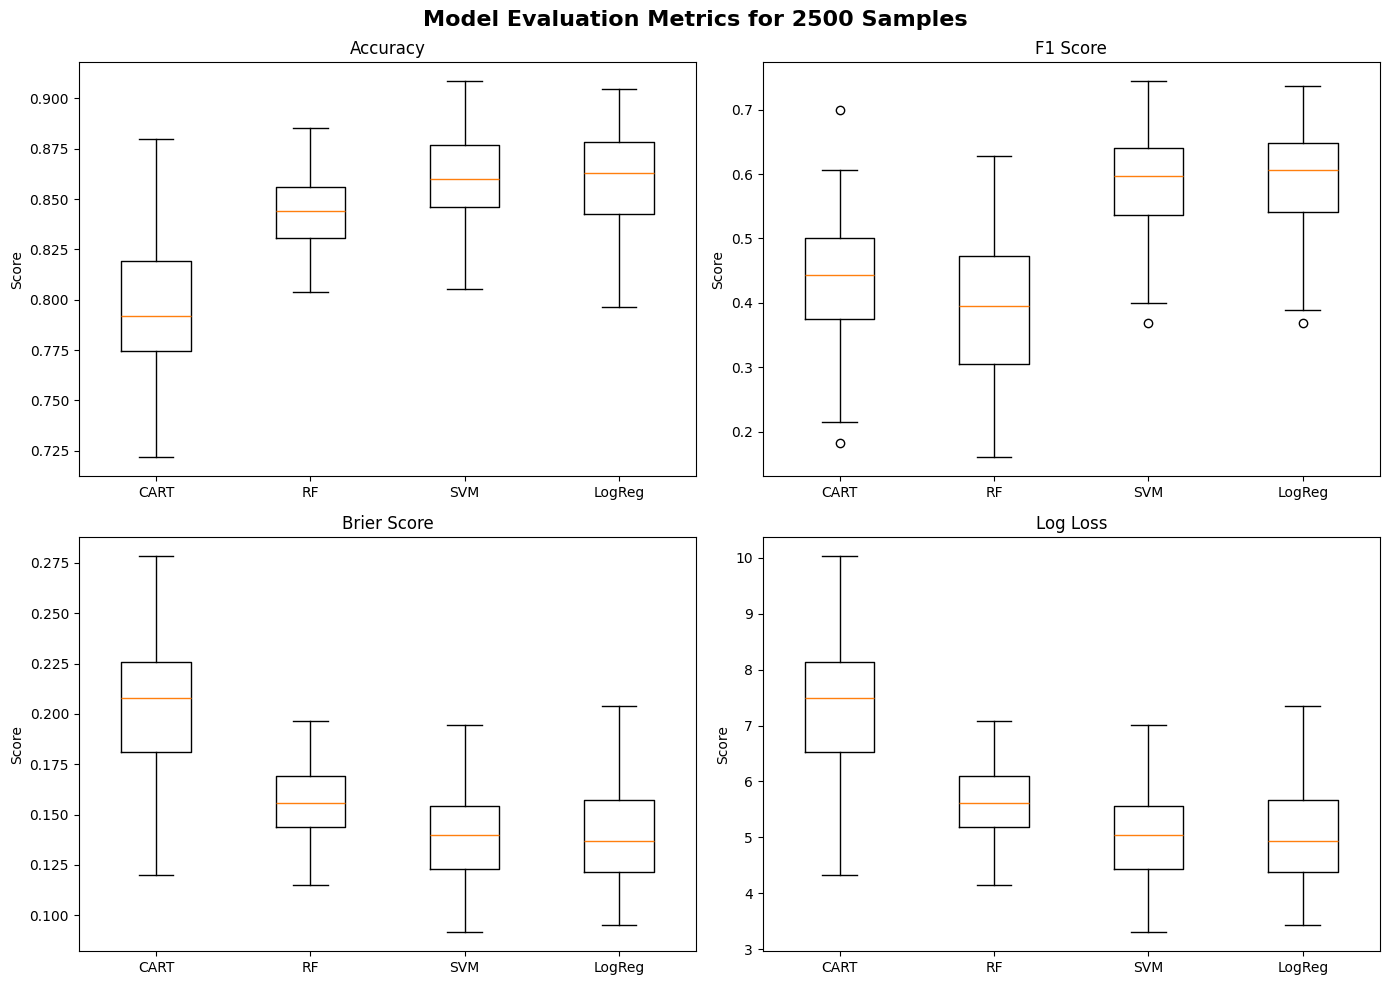

In [ ]:
_2500_results_cart_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_cart_unbalanced_2500.csv") 
_2500_results_rf_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_rf_unbalanced_2500.csv")
_2500_results_SVM_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_SVM_unbalanced_2500.csv")
_2500_results_logreg_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_logreg_unbalanced_2500.csv")


labels = ['CART', 'RF', 'SVM', 'LogReg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))


_2500_acc_cart = _2500_results_cart_u['accuracy'].to_numpy()
_2500_acc_rf = _2500_results_rf_u['accuracy'].to_numpy()
_2500_acc_SVM = _2500_results_SVM_u['accuracy'].to_numpy()
_2500_acc_logreg = _2500_results_logreg_u['accuracy'].to_numpy()

axs[0, 0].boxplot([_2500_acc_cart, _2500_acc_rf, _2500_acc_SVM, _2500_acc_logreg], tick_labels=labels)
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Score')


_2500_f1_cart = _2500_results_cart_u['f1_score'].to_numpy()
_2500_f1_rf = _2500_results_rf_u['f1_score'].to_numpy()
_2500_f1_SVM = _2500_results_SVM_u['f1_score'].to_numpy()
_2500_f1_logreg = _2500_results_logreg_u['f1_score'].to_numpy()

axs[0, 1].boxplot([_2500_f1_cart, _2500_f1_rf, _2500_f1_SVM, _2500_f1_logreg], tick_labels=labels)
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_ylabel('Score')


_2500_brier_cart = _2500_results_cart_u['brier_score'].to_numpy()
_2500_brier_rf = _2500_results_rf_u['brier_score'].to_numpy()
_2500_brier_SVM = _2500_results_SVM_u['brier_score'].to_numpy()
_2500_brier_logreg = _2500_results_logreg_u['brier_score'].to_numpy()

axs[1, 0].boxplot([_2500_brier_cart, _2500_brier_rf, _2500_brier_SVM, _2500_brier_logreg], tick_labels=labels)
axs[1, 0].set_title('Brier Score')
axs[1, 0].set_ylabel('Score')


_2500_log_loss_cart = _2500_results_cart_u['log_loss'].to_numpy()
_2500_log_loss_rf = _2500_results_rf_u['log_loss'].to_numpy()
_2500_log_loss_SVM = _2500_results_SVM_u['log_loss'].to_numpy()
_2500_log_loss_logreg = _2500_results_logreg_u['log_loss'].to_numpy()

axs[1, 1].boxplot([_2500_log_loss_cart, _2500_log_loss_rf, _2500_log_loss_SVM, _2500_log_loss_logreg], tick_labels=labels)
axs[1, 1].set_title('Log Loss')
axs[1, 1].set_ylabel('Score')


plt.suptitle('Model Evaluation Metrics for 2500 Samples', fontsize=16, fontweight='bold')
plt.tight_layout()  
plt.show()

# Nemenyi post-hoc test using scikit_posthocs
accuracy = pd.DataFrame({'CART': _2500_acc_cart, 'RF': _2500_acc_rf, 'SVM': _2500_acc_SVM, 'LogReg':_2500_acc_logreg})
print("=" * 70)
print("NEMENYI POST-HOC TEST (Accuracy)")
print("=" * 70)

# Use built-in Nemenyi test from scikit_posthocs
p_nemenyi = sp.posthoc_nemenyi_friedman(accuracy)

print("\nP-values (Lower Triangular):")
print(p_nemenyi.round(6))

# Create symmetric version for downstream analysis
p_nemenyi_sym = np.array(p_nemenyi, copy=True, dtype=float)
i_lower = np.tril_indices(p_nemenyi_sym.shape[0], -1)
p_nemenyi_sym[i_lower[1], i_lower[0]] = p_nemenyi_sym[i_lower]
np.fill_diagonal(p_nemenyi_sym, 1)

print("\nSymmetric P-value Matrix:")
print(pd.DataFrame(np.round(p_nemenyi_sym, 6), 
                   index=accuracy.columns, 
                   columns=accuracy.columns))


# Compute average ranks for CD diagram
ranks = np.array([rankdata(row) for row in accuracy.values])
mean_ranks = ranks.mean(axis=0)

# Convert mean_ranks to Series with proper index to match p-value matrix
mean_ranks_series = pd.Series(mean_ranks, index=accuracy.columns)

# Create CD diagram
print("=" * 70)
print("CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)")
print("=" * 70)

# Create symmetric p-value DataFrame for CD diagram
p_nemenyi_for_cd = pd.DataFrame(p_nemenyi_sym, 
                                 index=accuracy.columns, 
                                 columns=accuracy.columns)

# Use scikit_posthocs critical_difference_diagram with p-value matrix
sp.critical_difference_diagram(mean_ranks_series, p_nemenyi_for_cd, alpha=0.05)
plt.tight_layout()
plt.show()

#### 1000

C:\Users\wwide\AppData\Local\Temp\ipykernel_30460\941223751.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, 0].boxplot([_1000_acc_cart, _1000_acc_rf, _1000_acc_SVM, _1000_acc_logreg], labels=labels)
C:\Users\wwide\AppData\Local\Temp\ipykernel_30460\941223751.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, 1].boxplot([_1000_f1_cart, _1000_f1_rf, _1000_f1_SVM, _1000_f1_logreg], labels=labels)
C:\Users\wwide\AppData\Local\Temp\ipykernel_30460\941223751.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1, 0].boxplot([_1000_brier_cart, _1000_brier_rf, _1000_brier_SVM, _1000_brier_logreg], lab

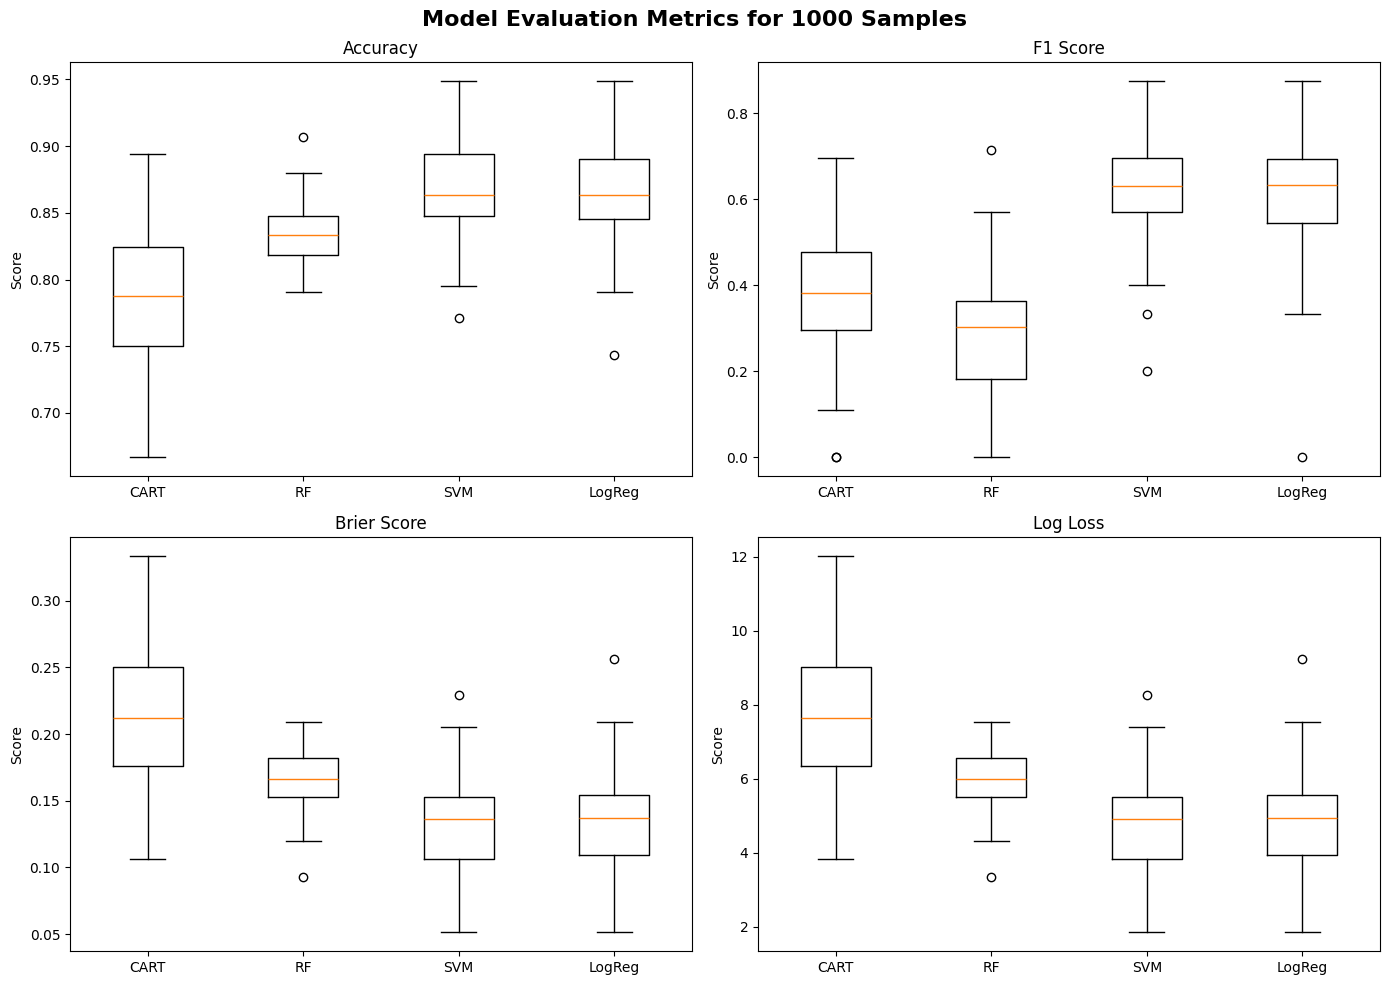

In [ ]:
_1000_results_cart_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_cart_unbalanced_1000.csv") 
_1000_results_rf_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_rf_unbalanced_1000.csv")
_1000_results_SVM_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_SVM_unbalanced_1000.csv")
_1000_results_logreg_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_logreg_unbalanced_1000.csv")


labels = ['CART', 'RF', 'SVM', 'LogReg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))


_1000_acc_cart = _1000_results_cart_u['accuracy'].to_numpy()
_1000_acc_rf = _1000_results_rf_u['accuracy'].to_numpy()
_1000_acc_SVM = _1000_results_SVM_u['accuracy'].to_numpy()
_1000_acc_logreg = _1000_results_logreg_u['accuracy'].to_numpy()

axs[0, 0].boxplot([_1000_acc_cart, _1000_acc_rf, _1000_acc_SVM, _1000_acc_logreg], tick_labels=labels)
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Score')


_1000_f1_cart = _1000_results_cart_u['f1_score'].to_numpy()
_1000_f1_rf = _1000_results_rf_u['f1_score'].to_numpy()
_1000_f1_SVM = _1000_results_SVM_u['f1_score'].to_numpy()
_1000_f1_logreg = _1000_results_logreg_u['f1_score'].to_numpy()

axs[0, 1].boxplot([_1000_f1_cart, _1000_f1_rf, _1000_f1_SVM, _1000_f1_logreg], tick_labels=labels)
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_ylabel('Score')


_1000_brier_cart = _1000_results_cart_u['brier_score'].to_numpy()
_1000_brier_rf = _1000_results_rf_u['brier_score'].to_numpy()
_1000_brier_SVM = _1000_results_SVM_u['brier_score'].to_numpy()
_1000_brier_logreg = _1000_results_logreg_u['brier_score'].to_numpy()

axs[1, 0].boxplot([_1000_brier_cart, _1000_brier_rf, _1000_brier_SVM, _1000_brier_logreg], tick_labels=labels)
axs[1, 0].set_title('Brier Score')
axs[1, 0].set_ylabel('Score')


_1000_log_loss_cart = _1000_results_cart_u['log_loss'].to_numpy()
_1000_log_loss_rf = _1000_results_rf_u['log_loss'].to_numpy()
_1000_log_loss_SVM = _1000_results_SVM_u['log_loss'].to_numpy()
_1000_log_loss_logreg = _1000_results_logreg_u['log_loss'].to_numpy()

axs[1, 1].boxplot([_1000_log_loss_cart, _1000_log_loss_rf, _1000_log_loss_SVM, _1000_log_loss_logreg], tick_labels=labels)
axs[1, 1].set_title('Log Loss')
axs[1, 1].set_ylabel('Score')


plt.suptitle('Model Evaluation Metrics for 1000 Samples', fontsize=16, fontweight='bold')
plt.tight_layout()  
plt.show()

# Nemenyi post-hoc test using scikit_posthocs
accuracy = pd.DataFrame({'CART': _1000_acc_cart, 'RF': _1000_acc_rf, 'SVM': _1000_acc_SVM, 'LogReg':_1000_acc_logreg})
print("=" * 70)
print("NEMENYI POST-HOC TEST (Accuracy)")
print("=" * 70)

# Use built-in Nemenyi test from scikit_posthocs
p_nemenyi = sp.posthoc_nemenyi_friedman(accuracy)

print("\nP-values (Lower Triangular):")
print(p_nemenyi.round(6))

# Create symmetric version for downstream analysis
p_nemenyi_sym = np.array(p_nemenyi, copy=True, dtype=float)
i_lower = np.tril_indices(p_nemenyi_sym.shape[0], -1)
p_nemenyi_sym[i_lower[1], i_lower[0]] = p_nemenyi_sym[i_lower]
np.fill_diagonal(p_nemenyi_sym, 1)

print("\nSymmetric P-value Matrix:")
print(pd.DataFrame(np.round(p_nemenyi_sym, 6), 
                   index=accuracy.columns, 
                   columns=accuracy.columns))


# Compute average ranks for CD diagram
ranks = np.array([rankdata(row) for row in accuracy.values])
mean_ranks = ranks.mean(axis=0)

# Convert mean_ranks to Series with proper index to match p-value matrix
mean_ranks_series = pd.Series(mean_ranks, index=accuracy.columns)

# Create CD diagram
print("=" * 70)
print("CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)")
print("=" * 70)

# Create symmetric p-value DataFrame for CD diagram
p_nemenyi_for_cd = pd.DataFrame(p_nemenyi_sym, 
                                 index=accuracy.columns, 
                                 columns=accuracy.columns)

# Use scikit_posthocs critical_difference_diagram with p-value matrix
sp.critical_difference_diagram(mean_ranks_series, p_nemenyi_for_cd, alpha=0.05)
plt.tight_layout()
plt.show()

#### 500

C:\Users\wwide\AppData\Local\Temp\ipykernel_30460\94772494.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, 0].boxplot([_500_acc_cart, _500_acc_rf, _500_acc_SVM, _500_acc_logreg], labels=labels)
C:\Users\wwide\AppData\Local\Temp\ipykernel_30460\94772494.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, 1].boxplot([_500_f1_cart, _500_f1_rf, _500_f1_SVM, _500_f1_logreg], labels=labels)
C:\Users\wwide\AppData\Local\Temp\ipykernel_30460\94772494.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1, 0].boxplot([_500_brier_cart, _500_brier_rf, _500_brier_SVM, _500_brier_logreg], labels=labels)
C:\

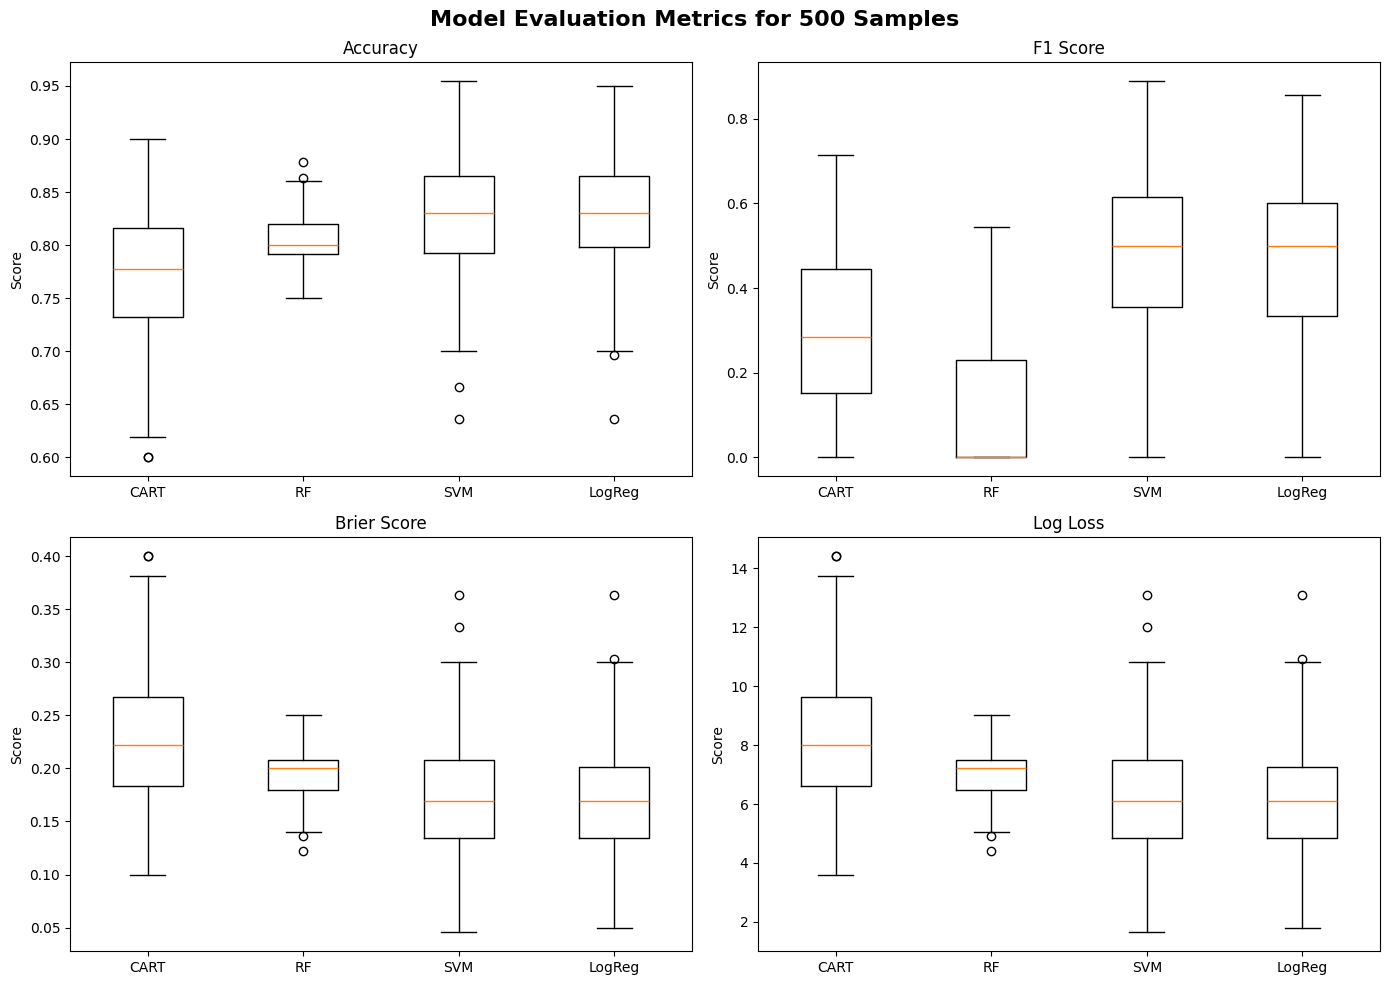

In [ ]:
_500_results_cart_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_cart_unbalanced_500.csv") 
_500_results_rf_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_rf_unbalanced_500.csv")
_500_results_SVM_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_SVM_unbalanced_500.csv")
_500_results_logreg_u = pd.read_csv("C:/Users/wwide/MVE441/bigdata/project_3/results_unbalanced/results_logreg_unbalanced_500.csv")


labels = ['CART', 'RF', 'SVM', 'LogReg']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))


_500_acc_cart = _500_results_cart_u['accuracy'].to_numpy()
_500_acc_rf = _500_results_rf_u['accuracy'].to_numpy()
_500_acc_SVM = _500_results_SVM_u['accuracy'].to_numpy()
_500_acc_logreg = _500_results_logreg_u['accuracy'].to_numpy()

axs[0, 0].boxplot([_500_acc_cart, _500_acc_rf, _500_acc_SVM, _500_acc_logreg], tick_labels=labels)
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Score')


_500_f1_cart = _500_results_cart_u['f1_score'].to_numpy()
_500_f1_rf = _500_results_rf_u['f1_score'].to_numpy()
_500_f1_SVM = _500_results_SVM_u['f1_score'].to_numpy()
_500_f1_logreg = _500_results_logreg_u['f1_score'].to_numpy()

axs[0, 1].boxplot([_500_f1_cart, _500_f1_rf, _500_f1_SVM, _500_f1_logreg], tick_labels=labels)
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_ylabel('Score')


_500_brier_cart = _500_results_cart_u['brier_score'].to_numpy()
_500_brier_rf = _500_results_rf_u['brier_score'].to_numpy()
_500_brier_SVM = _500_results_SVM_u['brier_score'].to_numpy()
_500_brier_logreg = _500_results_logreg_u['brier_score'].to_numpy()

axs[1, 0].boxplot([_500_brier_cart, _500_brier_rf, _500_brier_SVM, _500_brier_logreg], tick_labels=labels)
axs[1, 0].set_title('Brier Score')
axs[1, 0].set_ylabel('Score')


_500_log_loss_cart = _500_results_cart_u['log_loss'].to_numpy()
_500_log_loss_rf = _500_results_rf_u['log_loss'].to_numpy()
_500_log_loss_SVM = _500_results_SVM_u['log_loss'].to_numpy()
_500_log_loss_logreg = _500_results_logreg_u['log_loss'].to_numpy()

axs[1, 1].boxplot([_500_log_loss_cart, _500_log_loss_rf, _500_log_loss_SVM, _500_log_loss_logreg], tick_labels=labels)
axs[1, 1].set_title('Log Loss')
axs[1, 1].set_ylabel('Score')


plt.suptitle('Model Evaluation Metrics for 500 Samples', fontsize=16, fontweight='bold')
plt.tight_layout()  
plt.show()

# Nemenyi post-hoc test using scikit_posthocs
accuracy = pd.DataFrame({'CART': _500_acc_cart, 'RF': _500_acc_rf, 'SVM': _500_acc_SVM, 'LogReg':_500_acc_logreg})
print("=" * 70)
print("NEMENYI POST-HOC TEST (Accuracy)")
print("=" * 70)

# Use built-in Nemenyi test from scikit_posthocs
p_nemenyi = sp.posthoc_nemenyi_friedman(accuracy)

print("\nP-values (Lower Triangular):")
print(p_nemenyi.round(6))

# Create symmetric version for downstream analysis
p_nemenyi_sym = np.array(p_nemenyi, copy=True, dtype=float)
i_lower = np.tril_indices(p_nemenyi_sym.shape[0], -1)
p_nemenyi_sym[i_lower[1], i_lower[0]] = p_nemenyi_sym[i_lower]
np.fill_diagonal(p_nemenyi_sym, 1)

print("\nSymmetric P-value Matrix:")
print(pd.DataFrame(np.round(p_nemenyi_sym, 6), 
                   index=accuracy.columns, 
                   columns=accuracy.columns))


# Compute average ranks for CD diagram
ranks = np.array([rankdata(row) for row in accuracy.values])
mean_ranks = ranks.mean(axis=0)

# Convert mean_ranks to Series with proper index to match p-value matrix
mean_ranks_series = pd.Series(mean_ranks, index=accuracy.columns)

# Create CD diagram
print("=" * 70)
print("CRITICAL DIFFERENCE DIAGRAM (Nemenyi Test)")
print("=" * 70)

# Create symmetric p-value DataFrame for CD diagram
p_nemenyi_for_cd = pd.DataFrame(p_nemenyi_sym, 
                                 index=accuracy.columns, 
                                 columns=accuracy.columns)

# Use scikit_posthocs critical_difference_diagram with p-value matrix
sp.critical_difference_diagram(mean_ranks_series, p_nemenyi_for_cd, alpha=0.05)
plt.tight_layout()
plt.show()